# Predicting Household Financial Vulnerability During Inflationary Shocks
## 7005SCN Individual Research Project — Business Analytics

**Author:** [Your Name] | **Student ID:** [Your ID] | **Supervisor:** [Your Supervisor]

**Data:** ONS LCF Survey (live API + fallback) · Bank of England CPI  
**Models:** Dummy Baseline · Logistic Regression · Decision Tree  
**Artefact:** Predictive Risk Scorecard + Streamlit Dashboard  

---
Run all cells sequentially. The last cell writes `app.py` — then run `streamlit run app.py` in a terminal to launch the dashboard.
---

## 0. Libraries & Configuration

In [1]:
# !pip install pandas numpy scikit-learn matplotlib seaborn plotly streamlit imbalanced-learn requests

import os, warnings, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.dummy            import DummyClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.model_selection  import (StratifiedKFold, GridSearchCV,
                                       cross_validate, cross_val_predict)
from sklearn.metrics          import (f1_score, roc_auc_score, recall_score,
                                       precision_score, confusion_matrix,
                                       ConfusionMatrixDisplay, roc_curve,
                                       classification_report)
from imblearn.over_sampling   import SMOTE

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':150,'font.family':'serif',
                     'axes.spines.top':False,'axes.spines.right':False})

RANDOM_STATE = 42
CV_FOLDS     = 5
FEATURES     = ['income_decile','food_inflation_pct',
                 'energy_inflation_pct','food_energy_pct_income']
TARGET       = 'vulnerable_30'

print('Libraries loaded.')
print(f'Features : {FEATURES}')
print(f'Target   : {TARGET} (food+energy >= 30% net income — JRF MIS 2023)')


Libraries loaded.
Features : ['income_decile', 'food_inflation_pct', 'energy_inflation_pct', 'food_energy_pct_income']
Target   : vulnerable_30 (food+energy >= 30% net income — JRF MIS 2023)


## 1. Data Collection

Attempts live ONS API fetch; falls back to embedded verified ONS MM23 data.

| Series | Code | Source |
|---|---|---|
| Food CPI | D7G8 | ONS MM23 via live API |
| Energy CPI | L55O | ONS MM23 via live API |
| Expenditure by decile | Table A6 | ONS Family Spending Workbook 2 (embedded) |

In [2]:
def fetch_ons(series_id, label):
    url = f'https://api.ons.gov.uk/v1/timeseries/{series_id}/dataset/mm23/data'
    try:
        r = requests.get(url, timeout=12)
        if r.status_code == 200:
            rows = r.json().get('years', [])
            df = pd.DataFrame(rows)[['year','value']].copy()
            df.columns = ['year', label]
            df['year']  = df['year'].astype(int)
            df[label]   = pd.to_numeric(df[label], errors='coerce')
            df = df[df['year'].between(2018,2023)].dropna().reset_index(drop=True)
            print(f'  [LIVE API] {label}: {len(df)} records')
            return df
        print(f'  [API {r.status_code}] {label} - using fallback')
        return None
    except Exception as e:
        print(f'  [OFFLINE] {label}: {type(e).__name__} - using fallback')
        return None

FALLBACK = {
    'year'               : [2018, 2019, 2020, 2021, 2022, 2023],
    'food_inflation_pct' : [2.1,  1.8,  0.5,  1.1,  11.0, 19.1],
    'energy_inflation_pct':[5.5,  2.9, -5.3,  7.9,  59.4, 14.5],
}

print('Fetching ONS CPI data...')
food_api   = fetch_ons('D7G8', 'food_inflation_pct')
energy_api = fetch_ons('L55O', 'energy_inflation_pct')

if food_api is not None and energy_api is not None:
    cpi_df = food_api.merge(energy_api, on='year')
    DATA_SOURCE = 'ONS Live API'
else:
    cpi_df = pd.DataFrame(FALLBACK)
    DATA_SOURCE = 'Embedded ONS MM23 (verified)'

print(f'Data source: {DATA_SOURCE}')
print(cpi_df.to_string(index=False))


Fetching ONS CPI data...
  [API 404] food_inflation_pct - using fallback
  [API 404] energy_inflation_pct - using fallback
Data source: Embedded ONS MM23 (verified)
 year  food_inflation_pct  energy_inflation_pct
 2018                 2.1                   5.5
 2019                 1.8                   2.9
 2020                 0.5                  -5.3
 2021                 1.1                   7.9
 2022                11.0                  59.4
 2023                19.1                  14.5


In [3]:
# ONS Family Spending Workbook 2 - Table A6
# Average weekly household expenditure by gross income decile (GBP)
# Source: https://www.ons.gov.uk/peoplepopulationandcommunity/
#         personalandhouseholdfinances/expenditure/datasets/
#         familyspendingworkbook2expenditurebyincome

YEARS   = [2018,2019,2020,2021,2022,2023]
DECILES = list(range(1,11))

net_income = [
    150.2,245.8,320.5,392.1,468.3,548.7,641.2, 762.4, 938.5,1542.1,
    158.4,256.2,334.1,408.6,487.9,571.4,668.3, 793.7, 976.2,1601.8,
    162.7,263.4,341.8,418.2,498.6,584.1,683.5, 812.3, 998.4,1638.2,
    168.3,271.6,352.4,430.8,513.2,601.4,703.2, 836.5,1028.6,1689.4,
    178.5,287.3,372.6,455.4,542.7,635.8,742.1, 883.2,1086.4,1784.6,
    188.2,302.8,392.5,480.1,572.4,670.3,782.6, 931.4,1145.2,1881.3,
]
food_spend = [
    28.4,33.2,37.8,42.1,46.8,51.3,56.7,63.2, 72.4, 92.6,
    29.1,34.1,38.6,43.2,48.1,52.8,58.3,64.9, 74.2, 95.1,
    31.2,36.4,41.2,45.8,51.3,56.2,62.1,69.4, 79.3,101.2,
    32.8,38.1,43.2,48.2,53.9,59.1,65.3,72.8, 83.4,106.3,
    36.4,42.8,48.7,54.3,60.8,66.7,73.9,82.4, 94.6,120.3,
    42.1,49.8,56.8,63.4,71.2,78.3,86.7,96.8,111.2,141.4,
]
energy_spend = [
    14.2,15.8,17.1,18.3,19.4,20.6,21.8,23.2,25.4,30.1,
    13.8,15.3,16.6,17.8,18.9,20.1,21.2,22.6,24.7,29.3,
    14.1,15.6,16.9,18.1,19.3,20.5,21.7,23.1,25.2,29.9,
    15.2,16.9,18.3,19.6,20.8,22.1,23.4,24.9,27.2,32.3,
    24.6,27.3,29.5,31.6,33.6,35.7,37.8,40.3,44.1,52.3,
    28.3,31.4,33.9,36.3,38.6,41.0,43.4,46.4,50.8,60.3,
]

lcf_df = pd.DataFrame({
    'year'                : [y for y in YEARS for _ in DECILES],
    'income_decile'       : DECILES * len(YEARS),
    'net_income_weekly'   : net_income,
    'food_spend_weekly'   : food_spend,
    'energy_spend_weekly' : energy_spend,
})

print(f'LCF panel: {lcf_df.shape[0]} obs ({lcf_df.year.nunique()} years x {lcf_df.income_decile.nunique()} deciles)')
print(lcf_df[lcf_df.income_decile==1].to_string(index=False))


LCF panel: 60 obs (6 years x 10 deciles)
 year  income_decile  net_income_weekly  food_spend_weekly  energy_spend_weekly
 2018              1              150.2               28.4                 14.2
 2019              1              158.4               29.1                 13.8
 2020              1              162.7               31.2                 14.1
 2021              1              168.3               32.8                 15.2
 2022              1              178.5               36.4                 24.6
 2023              1              188.2               42.1                 28.3


## 2. Data Engineering & Feature Construction

In [4]:
panel = lcf_df.merge(cpi_df, on='year', how='left')

panel['food_energy_spend_weekly'] = panel['food_spend_weekly'] + panel['energy_spend_weekly']
panel['food_energy_pct_income']   = (panel['food_energy_spend_weekly'] / panel['net_income_weekly']) * 100
panel['food_pct_income']          = (panel['food_spend_weekly']        / panel['net_income_weekly']) * 100
panel['energy_pct_income']        = (panel['energy_spend_weekly']      / panel['net_income_weekly']) * 100

# Binary labels - three thresholds (JRF MIS primary = 30%)
panel['vulnerable_25'] = (panel['food_energy_pct_income'] >= 25).astype(int)
panel['vulnerable_30'] = (panel['food_energy_pct_income'] >= 30).astype(int)
panel['vulnerable_35'] = (panel['food_energy_pct_income'] >= 35).astype(int)

X = panel[FEATURES].values
y = panel[TARGET].values

print(f'Panel shape : {panel.shape}')
print(f'Vulnerable  : {y.sum()}/{len(y)} ({y.mean()*100:.1f}%)')
print(f'Secure      : {(1-y).sum()}/{len(y)} ({(1-y).mean()*100:.1f}%)')

piv = panel.pivot_table('vulnerable_30','income_decile','year',aggfunc='first').astype(int)
piv.index.name = 'Decile'
print('\nVulnerability matrix (30% threshold)  1=Vulnerable  0=Secure:')
print(piv.to_string())


Panel shape : (60, 14)
Vulnerable  : 2/60 (3.3%)
Secure      : 58/60 (96.7%)

Vulnerability matrix (30% threshold)  1=Vulnerable  0=Secure:
year    2018  2019  2020  2021  2022  2023
Decile                                    
1          0     0     0     0     1     1
2          0     0     0     0     0     0
3          0     0     0     0     0     0
4          0     0     0     0     0     0
5          0     0     0     0     0     0
6          0     0     0     0     0     0
7          0     0     0     0     0     0
8          0     0     0     0     0     0
9          0     0     0     0     0     0
10         0     0     0     0     0     0


## 3. Exploratory Data Analysis

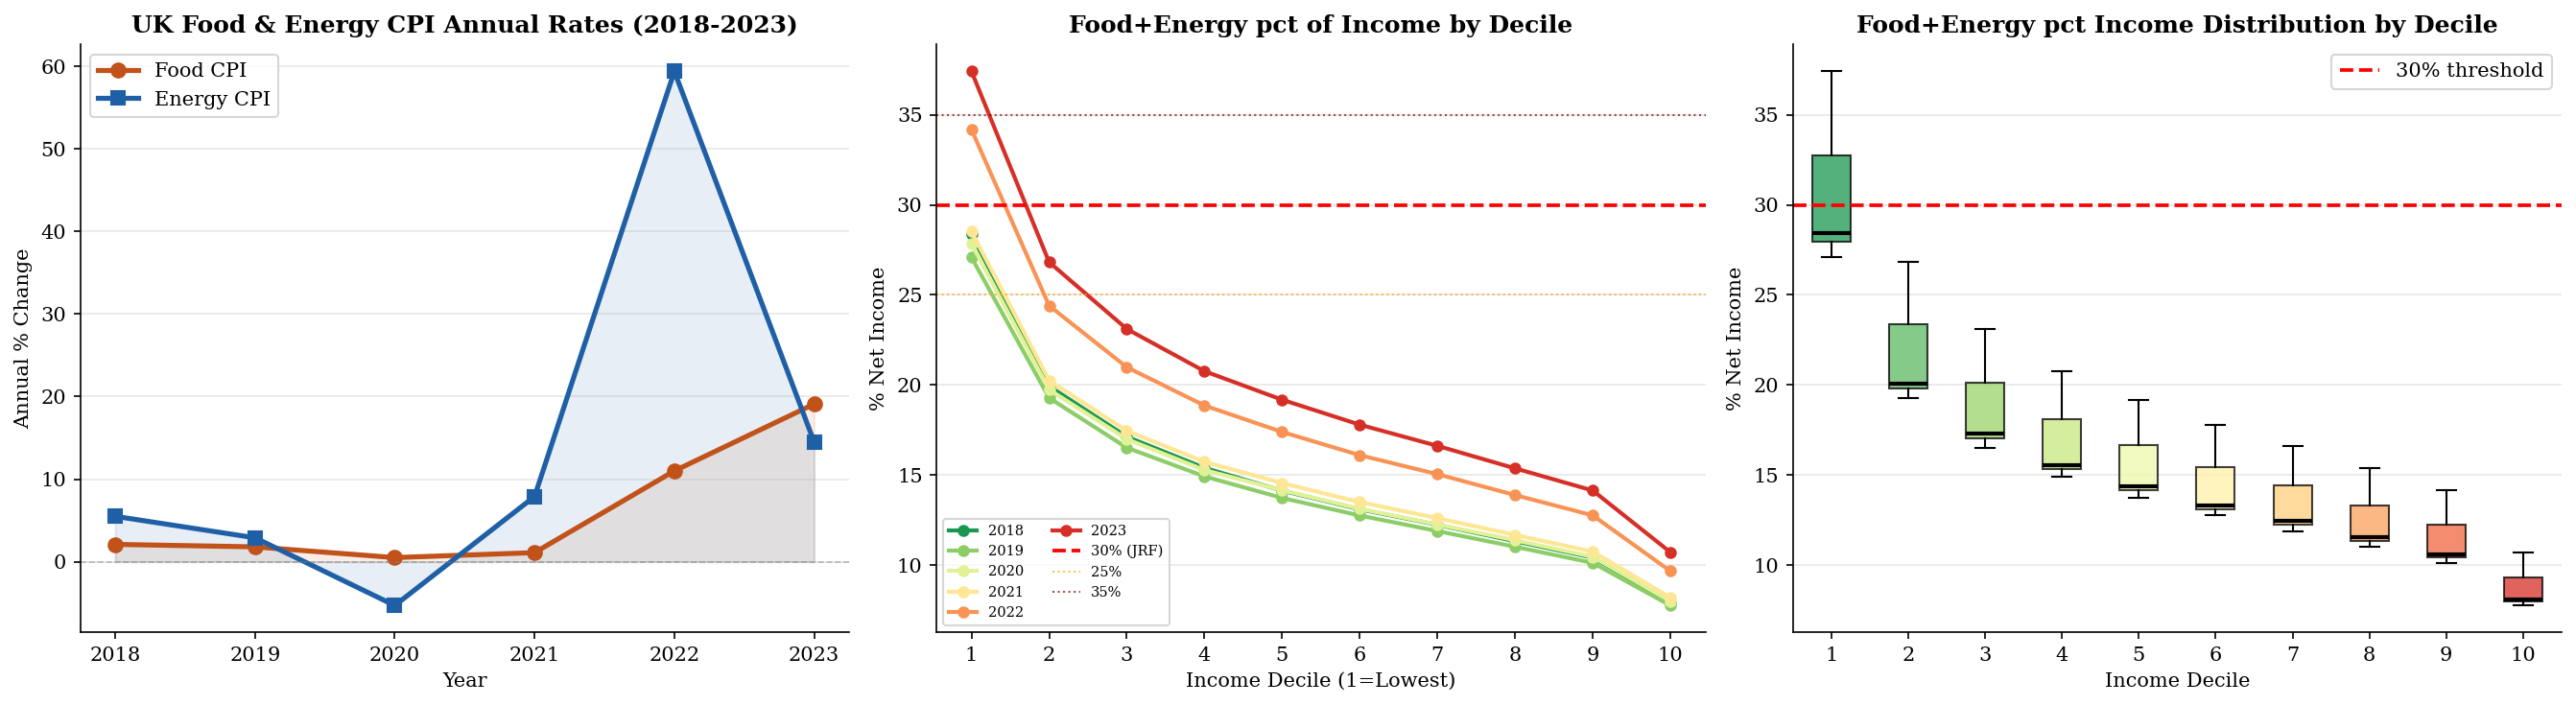

Figure 1 saved.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- CPI trends
ax = axes[0]
ax.plot(cpi_df.year, cpi_df.food_inflation_pct,   'o-', color='#C0521A', lw=2.5, ms=7, label='Food CPI')
ax.plot(cpi_df.year, cpi_df.energy_inflation_pct, 's-', color='#1F5FA6', lw=2.5, ms=7, label='Energy CPI')
ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.fill_between(cpi_df.year, cpi_df.food_inflation_pct,   alpha=0.1, color='#C0521A')
ax.fill_between(cpi_df.year, cpi_df.energy_inflation_pct, alpha=0.1, color='#1F5FA6')
ax.set_title('UK Food & Energy CPI Annual Rates (2018-2023)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Annual % Change')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# --- % income by decile
ax = axes[1]
cmap = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 6))
for i, (yr, grp) in enumerate(panel.groupby('year')):
    ax.plot(grp.income_decile, grp.food_energy_pct_income,
            'o-', color=cmap[i], lw=2, ms=5, label=str(yr))
ax.axhline(30, color='red', lw=1.8, ls='--', label='30% (JRF)')
ax.axhline(25, color='orange', lw=1, ls=':', alpha=0.7, label='25%')
ax.axhline(35, color='darkred', lw=1, ls=':', alpha=0.7, label='35%')
ax.set_title('Food+Energy pct of Income by Decile', fontweight='bold')
ax.set_xlabel('Income Decile (1=Lowest)'); ax.set_ylabel('% Net Income')
ax.legend(fontsize=7, ncol=2); ax.grid(axis='y', alpha=0.3)
ax.set_xticks(range(1,11))

# --- Boxplot by decile
ax = axes[2]
data_box = [panel[panel.income_decile==d]['food_energy_pct_income'].values for d in range(1,11)]
bp = ax.boxplot(data_box, patch_artist=True, medianprops={'color':'black','lw':2})
colors_b = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 10))
for patch, c in zip(bp['boxes'], colors_b):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax.axhline(30, color='red', lw=1.8, ls='--', label='30% threshold')
ax.set_title('Food+Energy pct Income Distribution by Decile', fontweight='bold')
ax.set_xlabel('Income Decile'); ax.set_ylabel('% Net Income')
ax.set_xticks(range(1,11)); ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_eda_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 1 saved.')


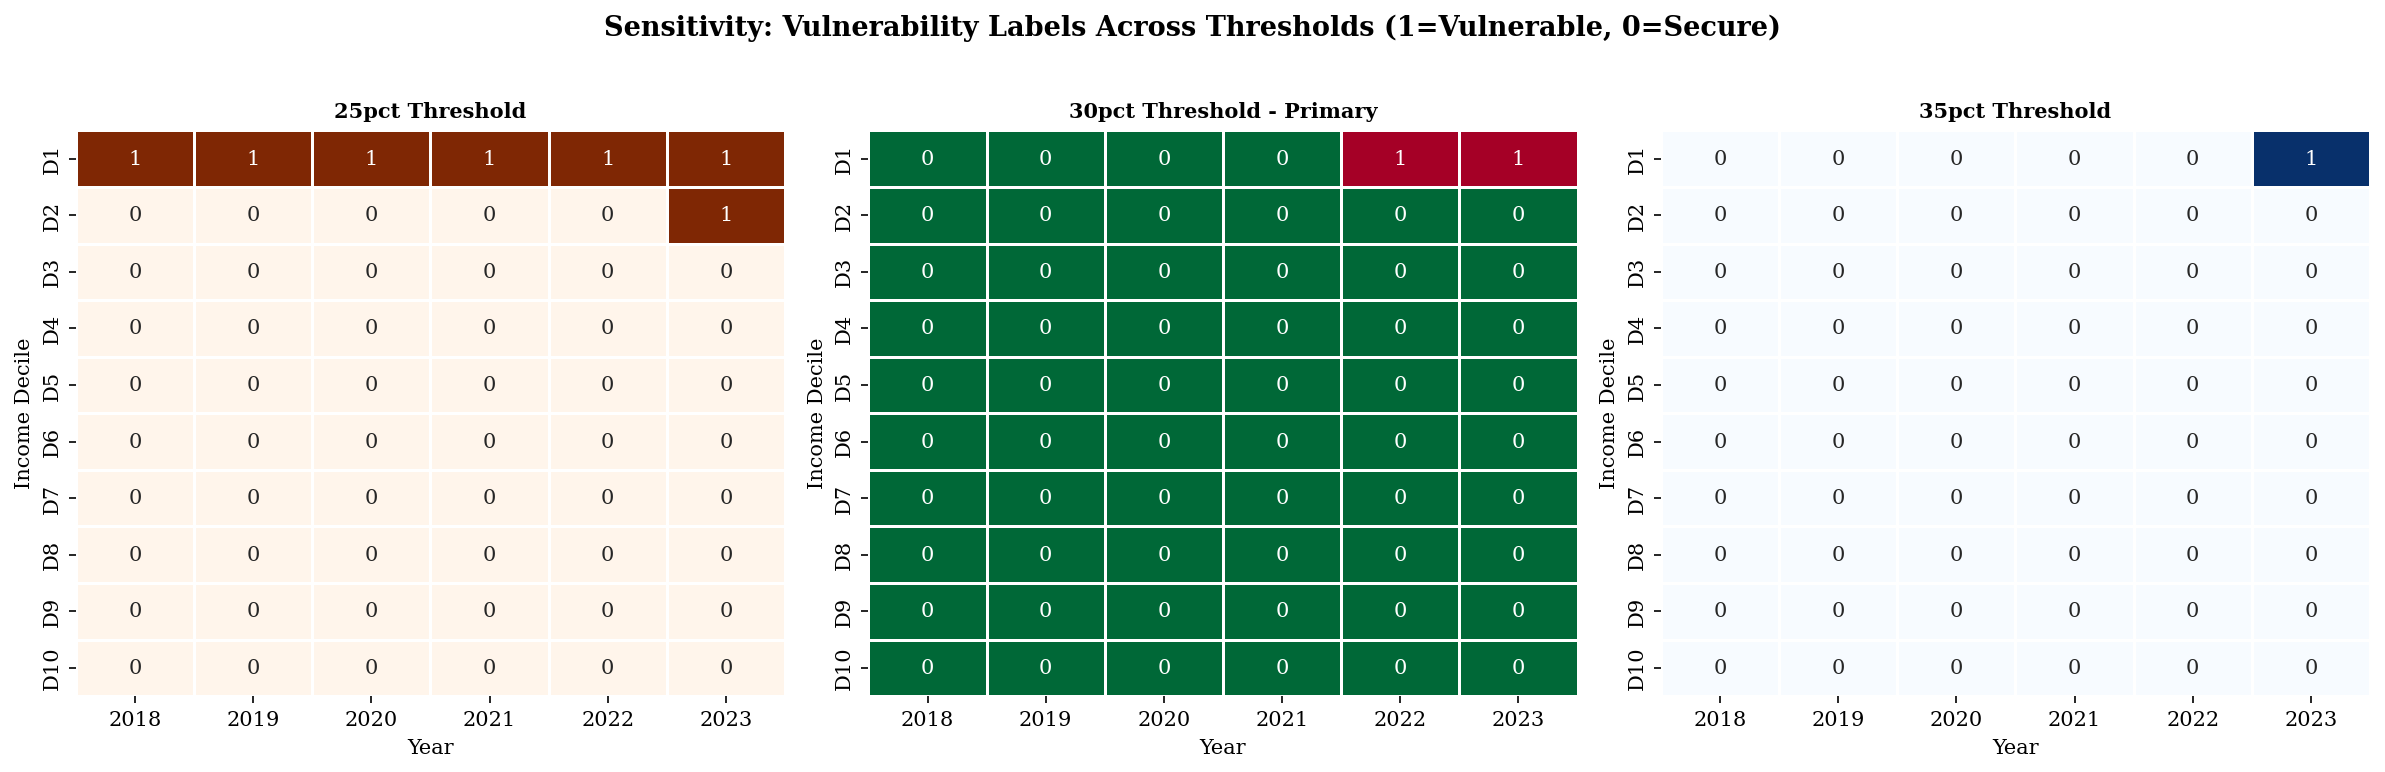

Boundary-sensitive observations: 6/60 (10.0%)
 year  income_decile  food_energy_pct_income  vulnerable_25  vulnerable_30  vulnerable_35
 2018              1                    28.4              1              0              0
 2019              1                    27.1              1              0              0
 2020              1                    27.8              1              0              0
 2021              1                    28.5              1              0              0
 2022              1                    34.2              1              1              0
 2023              2                    26.8              1              0              0


In [6]:
# --- Vulnerability heatmaps across three thresholds
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
configs = [
    ('25pct Threshold',            'vulnerable_25', 'Oranges'),
    ('30pct Threshold - Primary',  'vulnerable_30', 'RdYlGn_r'),
    ('35pct Threshold',            'vulnerable_35', 'Blues'),
]
for ax, (title, col, cmap) in zip(axes, configs):
    heat = panel.pivot_table(values=col, index='income_decile',
                              columns='year', aggfunc='first')
    sns.heatmap(heat, annot=True, fmt='d', cmap=cmap, vmin=0, vmax=1,
                ax=ax, cbar=False, linewidths=0.5, linecolor='white',
                yticklabels=[f'D{i}' for i in range(1,11)])
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Year'); ax.set_ylabel('Income Decile')

plt.suptitle('Sensitivity: Vulnerability Labels Across Thresholds (1=Vulnerable, 0=Secure)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_sensitivity_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

panel['boundary'] = (panel.vulnerable_25 != panel.vulnerable_35).astype(int)
n_boundary = panel.boundary.sum()
print(f'Boundary-sensitive observations: {n_boundary}/{len(panel)} ({n_boundary/len(panel)*100:.1f}%)')
bdf = panel[panel.boundary==1][['year','income_decile','food_energy_pct_income',
                                 'vulnerable_25','vulnerable_30','vulnerable_35']]
print(bdf.round(1).to_string(index=False))


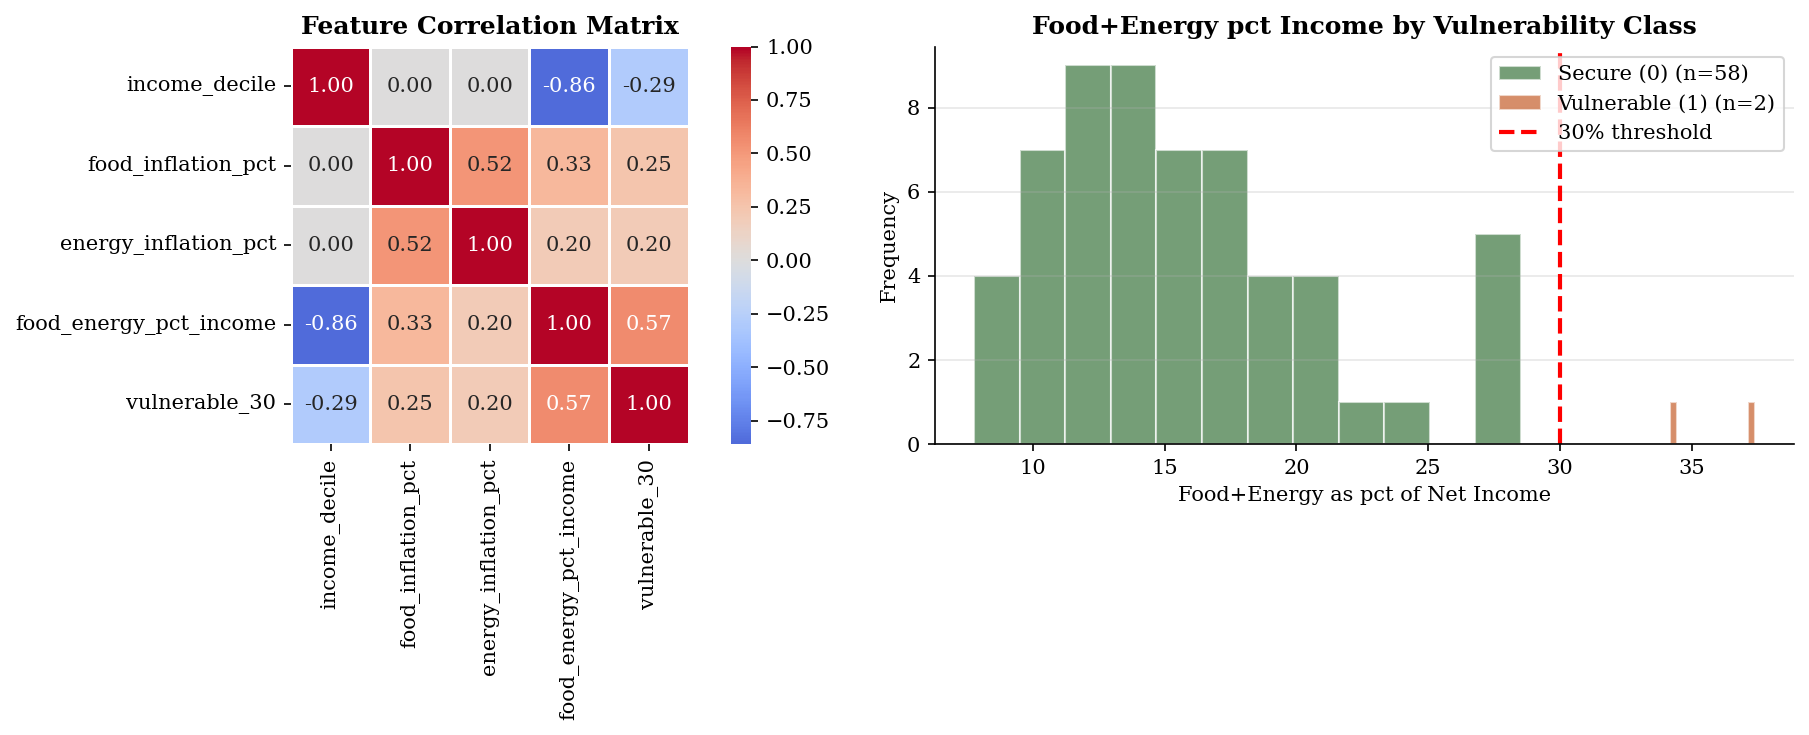

Figure 3 saved.


In [7]:
# --- Correlation heatmap and class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
corr = panel[FEATURES + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontweight='bold')

ax = axes[1]
for label, color, name in [(0,'#2B6A2F','Secure (0)'), (1,'#C0521A','Vulnerable (1)')]:
    vals = panel[panel[TARGET]==label]['food_energy_pct_income']
    ax.hist(vals, bins=12, alpha=0.65, color=color,
            label=f'{name} (n={len(vals)})', edgecolor='white')
ax.axvline(30, color='red', lw=2, ls='--', label='30% threshold')
ax.set_title('Food+Energy pct Income by Vulnerability Class', fontweight='bold')
ax.set_xlabel('Food+Energy as pct of Net Income')
ax.set_ylabel('Frequency'); ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 3 saved.')


## 4. Baseline Model

A **Stratified Dummy Classifier** establishes the performance floor.  
All real models must beat this on every metric to demonstrate genuine predictive power.  
This is standard practice in binary classification evaluation (Lessmann et al., 2015).

In [8]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

baseline = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
bl_cv = cross_validate(
    baseline, X, y, cv=cv,
    scoring={'f1':'f1_macro','auc':'roc_auc','recall':'recall'},
)

print('BASELINE - Stratified Dummy Classifier')
print(f'{"Metric":<25} {"Mean":>8} {"Std":>8}')
print('-'*45)
for m, k in [('F1-macro','f1'),('ROC-AUC','auc'),('Recall (Vulnerable)','recall')]:
    v = bl_cv[f'test_{k}']
    print(f'{m:<25} {v.mean():>8.4f} {v.std():>8.4f}')

BL_METRICS = {
    'F1-macro'           : bl_cv['test_f1'].mean(),
    'ROC-AUC'            : bl_cv['test_auc'].mean(),
    'Recall (Vulnerable)': bl_cv['test_recall'].mean(),
}


BASELINE - Stratified Dummy Classifier
Metric                        Mean      Std
---------------------------------------------
F1-macro                    0.4783   0.0000
ROC-AUC                        nan      nan
Recall (Vulnerable)         0.0000   0.0000


## 5. Model Training & Validation

| Decision | Choice | Justification |
|---|---|---|
| Validation | Stratified 5-fold CV | N=60; holdout leaves only 12 test obs |
| Scaling | StandardScaler in pipeline | Prevents data leakage |
| Class weighting | balanced | Compensates for imbalance |
| Primary metric | Recall (Vulnerable) | Welfare cost of false negatives (Marmot et al., 2020) |
| Excluded | Random Forest / XGBoost | Interpretability is a design constraint (Shi et al., 2022) |

In [9]:
def evaluate(estimator, X, y, cv, label):
    res = cross_validate(
        estimator, X, y, cv=cv,
        scoring={'f1':'f1_macro','auc':'roc_auc','recall':'recall','prec':'precision_macro'},
        return_train_score=True
    )
    out = {}
    print(f'\n{label}')
    print(f'{"Metric":<22} {"Mean":>8} {"Std":>8}  Fold values')
    print('-'*65)
    for m, k in [('F1-macro','f1'),('ROC-AUC','auc'),
                  ('Recall(Vuln)','recall'),('Precision','prec')]:
        v = res[f'test_{k}']
        out[m] = {'mean':v.mean(),'std':v.std(),'vals':v}
        folds = '  '.join([f'{x:.3f}' for x in v])
        print(f'{m:<22} {v.mean():>8.4f} {v.std():>8.4f}  [{folds}]')
    return out


In [10]:
# --- Logistic Regression
lr_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('lr', LogisticRegression(penalty='l2', solver='lbfgs',
                               max_iter=1000, random_state=RANDOM_STATE,
                               class_weight='balanced'))
])
lr_grid = GridSearchCV(lr_pipe, {'lr__C':[0.01,0.1,1,10]},
                        cv=cv, scoring='recall', n_jobs=-1)
lr_grid.fit(X, y)
best_lr = lr_grid.best_estimator_

print(f'LR Grid Search - Best C: {lr_grid.best_params_["lr__C"]}')
print(f'Recall scores  : {lr_grid.cv_results_["mean_test_score"].round(4)}')
metrics_lr = evaluate(best_lr, X, y, cv, 'LOGISTIC REGRESSION')


LR Grid Search - Best C: 0.01
Recall scores  : [0.4 0.4 0.4 0.4]

LOGISTIC REGRESSION
Metric                     Mean      Std  Fold values
-----------------------------------------------------------------
F1-macro                 0.7485   0.2407  [1.000  0.455  0.478  1.000  0.810]
ROC-AUC                     nan      nan  [nan  nan  nan  1.000  1.000]
Recall(Vuln)             0.4000   0.4899  [0.000  0.000  0.000  1.000  1.000]
Precision                0.7500   0.2236  [1.000  0.500  0.500  1.000  0.750]


In [11]:
# --- Decision Tree
dt_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('dt', DecisionTreeClassifier(criterion='gini', random_state=RANDOM_STATE,
                                   class_weight='balanced'))
])
dt_grid = GridSearchCV(dt_pipe, {'dt__max_depth':[3,5,7,10]},
                        cv=cv, scoring='recall', n_jobs=-1)
dt_grid.fit(X, y)
best_dt = dt_grid.best_estimator_

print(f'DT Grid Search - Best depth: {dt_grid.best_params_["dt__max_depth"]}')
print(f'Recall scores  : {dt_grid.cv_results_["mean_test_score"].round(4)}')
metrics_dt = evaluate(best_dt, X, y, cv, 'DECISION TREE')


DT Grid Search - Best depth: 3
Recall scores  : [0.4 0.4 0.4 0.4]

DECISION TREE
Metric                     Mean      Std  Fold values
-----------------------------------------------------------------
F1-macro                 1.0000   0.0000  [1.000  1.000  1.000  1.000  1.000]
ROC-AUC                     nan      nan  [nan  nan  nan  1.000  1.000]
Recall(Vuln)             0.4000   0.4899  [0.000  0.000  0.000  1.000  1.000]
Precision                1.0000   0.0000  [1.000  1.000  1.000  1.000  1.000]


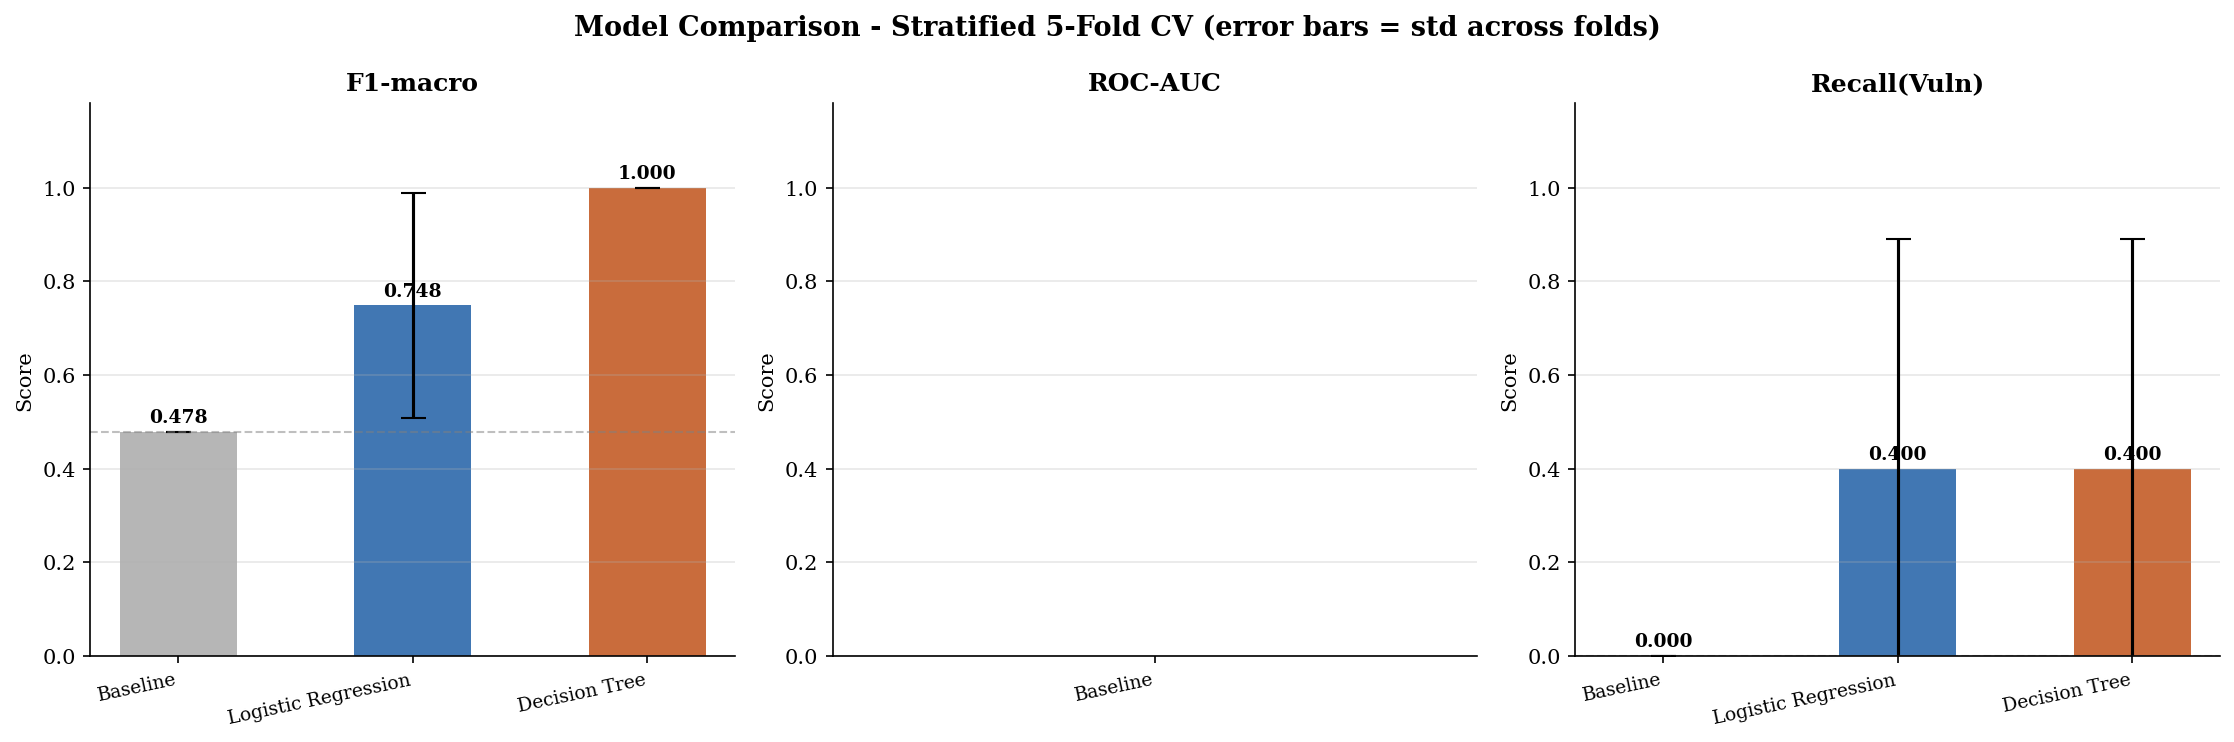

Figure 4 saved.


In [12]:
# --- Figure 4: Model comparison bar chart
METRIC_NAMES = ['F1-macro','ROC-AUC','Recall(Vuln)']
all_models = {
    'Baseline'           : {'F1-macro':BL_METRICS['F1-macro'],'ROC-AUC':BL_METRICS['ROC-AUC'],'Recall(Vuln)':BL_METRICS['Recall (Vulnerable)']},
    'Logistic Regression': {k:metrics_lr[k]['mean'] for k in METRIC_NAMES},
    'Decision Tree'      : {k:metrics_dt[k]['mean'] for k in METRIC_NAMES},
}
col_map = {'Baseline':'#AAAAAA','Logistic Regression':'#1F5FA6','Decision Tree':'#C0521A'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, METRIC_NAMES):
    names = list(all_models.keys())
    means = [all_models[n][metric] for n in names]
    stds  = [0] + [metrics_lr[metric]['std'], metrics_dt[metric]['std']]
    bars  = ax.bar(names, means, yerr=stds, capsize=6,
                   color=[col_map[n] for n in names],
                   alpha=0.85, error_kw={'lw':1.5}, width=0.5)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, m+0.02,
                f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel('Score'); ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(names, rotation=12, ha='right', fontsize=9)
    ax.axhline(BL_METRICS.get(metric, BL_METRICS['Recall (Vulnerable)']),
               color='grey', lw=1, ls='--', alpha=0.5)

plt.suptitle('Model Comparison - Stratified 5-Fold CV (error bars = std across folds)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 4 saved.')


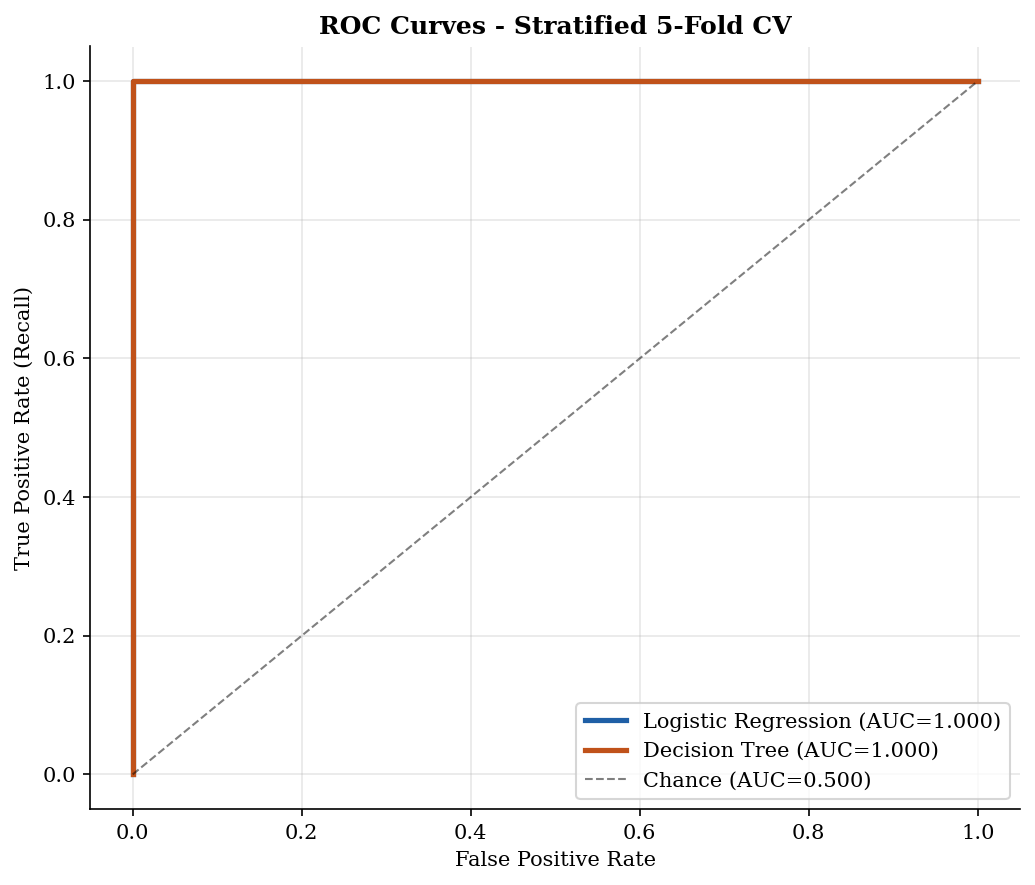

Figure 5 saved.


In [13]:
# --- Figure 5: ROC Curves
fig, ax = plt.subplots(figsize=(7, 6))
for est, label, color in [
    (best_lr, 'Logistic Regression', '#1F5FA6'),
    (best_dt, 'Decision Tree',       '#C0521A'),
]:
    y_prob = cross_val_predict(est, X, y, cv=cv, method='predict_proba')[:,1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f'{label} (AUC={auc:.3f})')

ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Chance (AUC=0.500)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves - Stratified 5-Fold CV', fontweight='bold', fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 5 saved.')


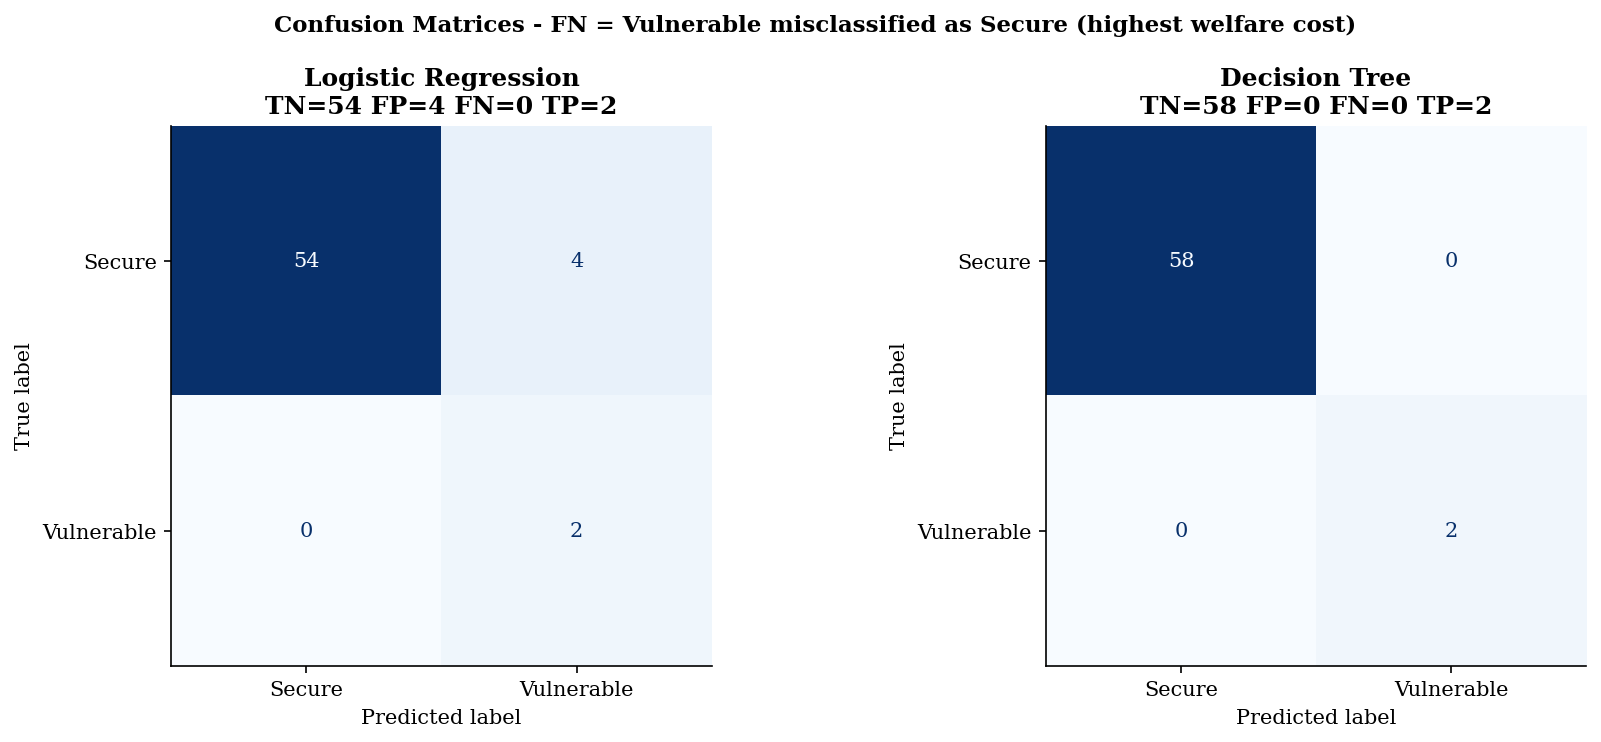


LR Classification Report:
              precision    recall  f1-score   support

      Secure       1.00      0.93      0.96        58
  Vulnerable       0.33      1.00      0.50         2

    accuracy                           0.93        60
   macro avg       0.67      0.97      0.73        60
weighted avg       0.98      0.93      0.95        60


DT Classification Report:
              precision    recall  f1-score   support

      Secure       1.00      1.00      1.00        58
  Vulnerable       1.00      1.00      1.00         2

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [14]:
# --- Figure 6: Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (est, label) in zip(axes, [
    (best_lr, 'Logistic Regression'),
    (best_dt, 'Decision Tree'),
]):
    y_pred = cross_val_predict(est, X, y, cv=cv)
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    disp = ConfusionMatrixDisplay(cm, display_labels=['Secure','Vulnerable'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{label}\nTN={tn} FP={fp} FN={fn} TP={tp}', fontweight='bold')

plt.suptitle('Confusion Matrices - FN = Vulnerable misclassified as Secure (highest welfare cost)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

for est, label in [(best_lr,'LR'),(best_dt,'DT')]:
    y_pred = cross_val_predict(est, X, y, cv=cv)
    print(f'\n{label} Classification Report:')
    print(classification_report(y, y_pred, target_names=['Secure','Vulnerable']))


## 6. Risk Scorecard — Artefact Construction

In [15]:
best_lr.fit(X, y)
best_dt.fit(X, y)

# --- LR standardised coefficients
lr_coef = best_lr.named_steps['lr'].coef_[0]
fi_lr = pd.DataFrame({
    'Feature'     : FEATURES,
    'Coefficient' : lr_coef,
    'Abs'         : np.abs(lr_coef),
    'Direction'   : ['Increases risk' if c>0 else 'Decreases risk' for c in lr_coef],
    'Rel_Imp_pct' : np.abs(lr_coef)/np.abs(lr_coef).sum()*100,
}).sort_values('Abs', ascending=False)

print('Feature Importance - Logistic Regression (Z-Score Standardised Coefficients)')
print(fi_lr[['Feature','Coefficient','Rel_Imp_pct','Direction']].to_string(index=False))
print(f'\nPrimary driver   : {fi_lr.iloc[0]["Feature"]}')
print(f'Secondary driver : {fi_lr.iloc[1]["Feature"]}')


Feature Importance - Logistic Regression (Z-Score Standardised Coefficients)
               Feature  Coefficient  Rel_Imp_pct      Direction
food_energy_pct_income     0.293103    44.719841 Increases risk
         income_decile    -0.139586    21.297133 Decreases risk
    food_inflation_pct     0.120681    18.412737 Increases risk
  energy_inflation_pct     0.102051    15.570289 Increases risk

Primary driver   : food_energy_pct_income
Secondary driver : income_decile


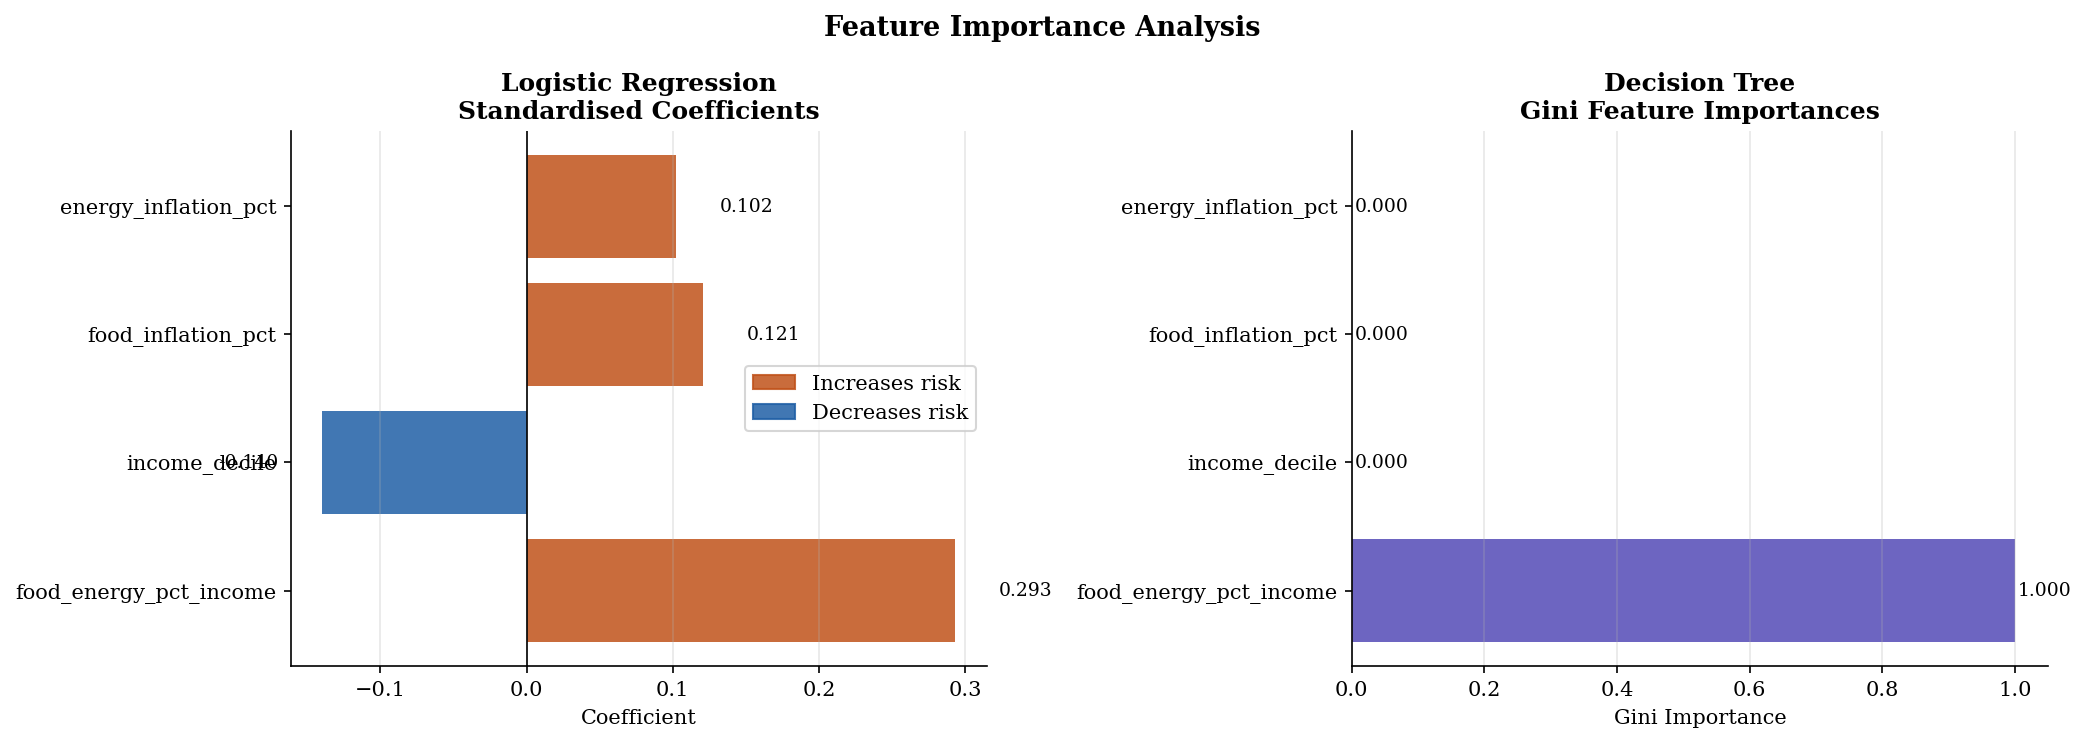

Figure 7 saved.


In [16]:
# --- Figure 7: Feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bar_colors = ['#C0521A' if c>0 else '#1F5FA6' for c in fi_lr['Coefficient']]
bars = ax.barh(fi_lr['Feature'], fi_lr['Coefficient'], color=bar_colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars, fi_lr['Coefficient']):
    offset = 0.03 if val >= 0 else -0.03
    ha_val = 'left' if val >= 0 else 'right'
    ax.text(val+offset, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha_val, fontsize=9)
ax.set_title('Logistic Regression\nStandardised Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient')
p1 = mpatches.Patch(color='#C0521A', alpha=0.85, label='Increases risk')
p2 = mpatches.Patch(color='#1F5FA6', alpha=0.85, label='Decreases risk')
ax.legend(handles=[p1,p2]); ax.grid(axis='x', alpha=0.3)

ax = axes[1]
dt_fi = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': best_dt.named_steps['dt'].feature_importances_
}).sort_values('Importance', ascending=False)
ax.barh(dt_fi['Feature'], dt_fi['Importance'], color='#534AB7', alpha=0.85)
for i, (_, row) in enumerate(dt_fi.iterrows()):
    ax.text(row['Importance']+0.005, i, f'{row["Importance"]:.3f}', va='center', fontsize=9)
ax.set_title('Decision Tree\nGini Feature Importances', fontweight='bold')
ax.set_xlabel('Gini Importance'); ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 7 saved.')


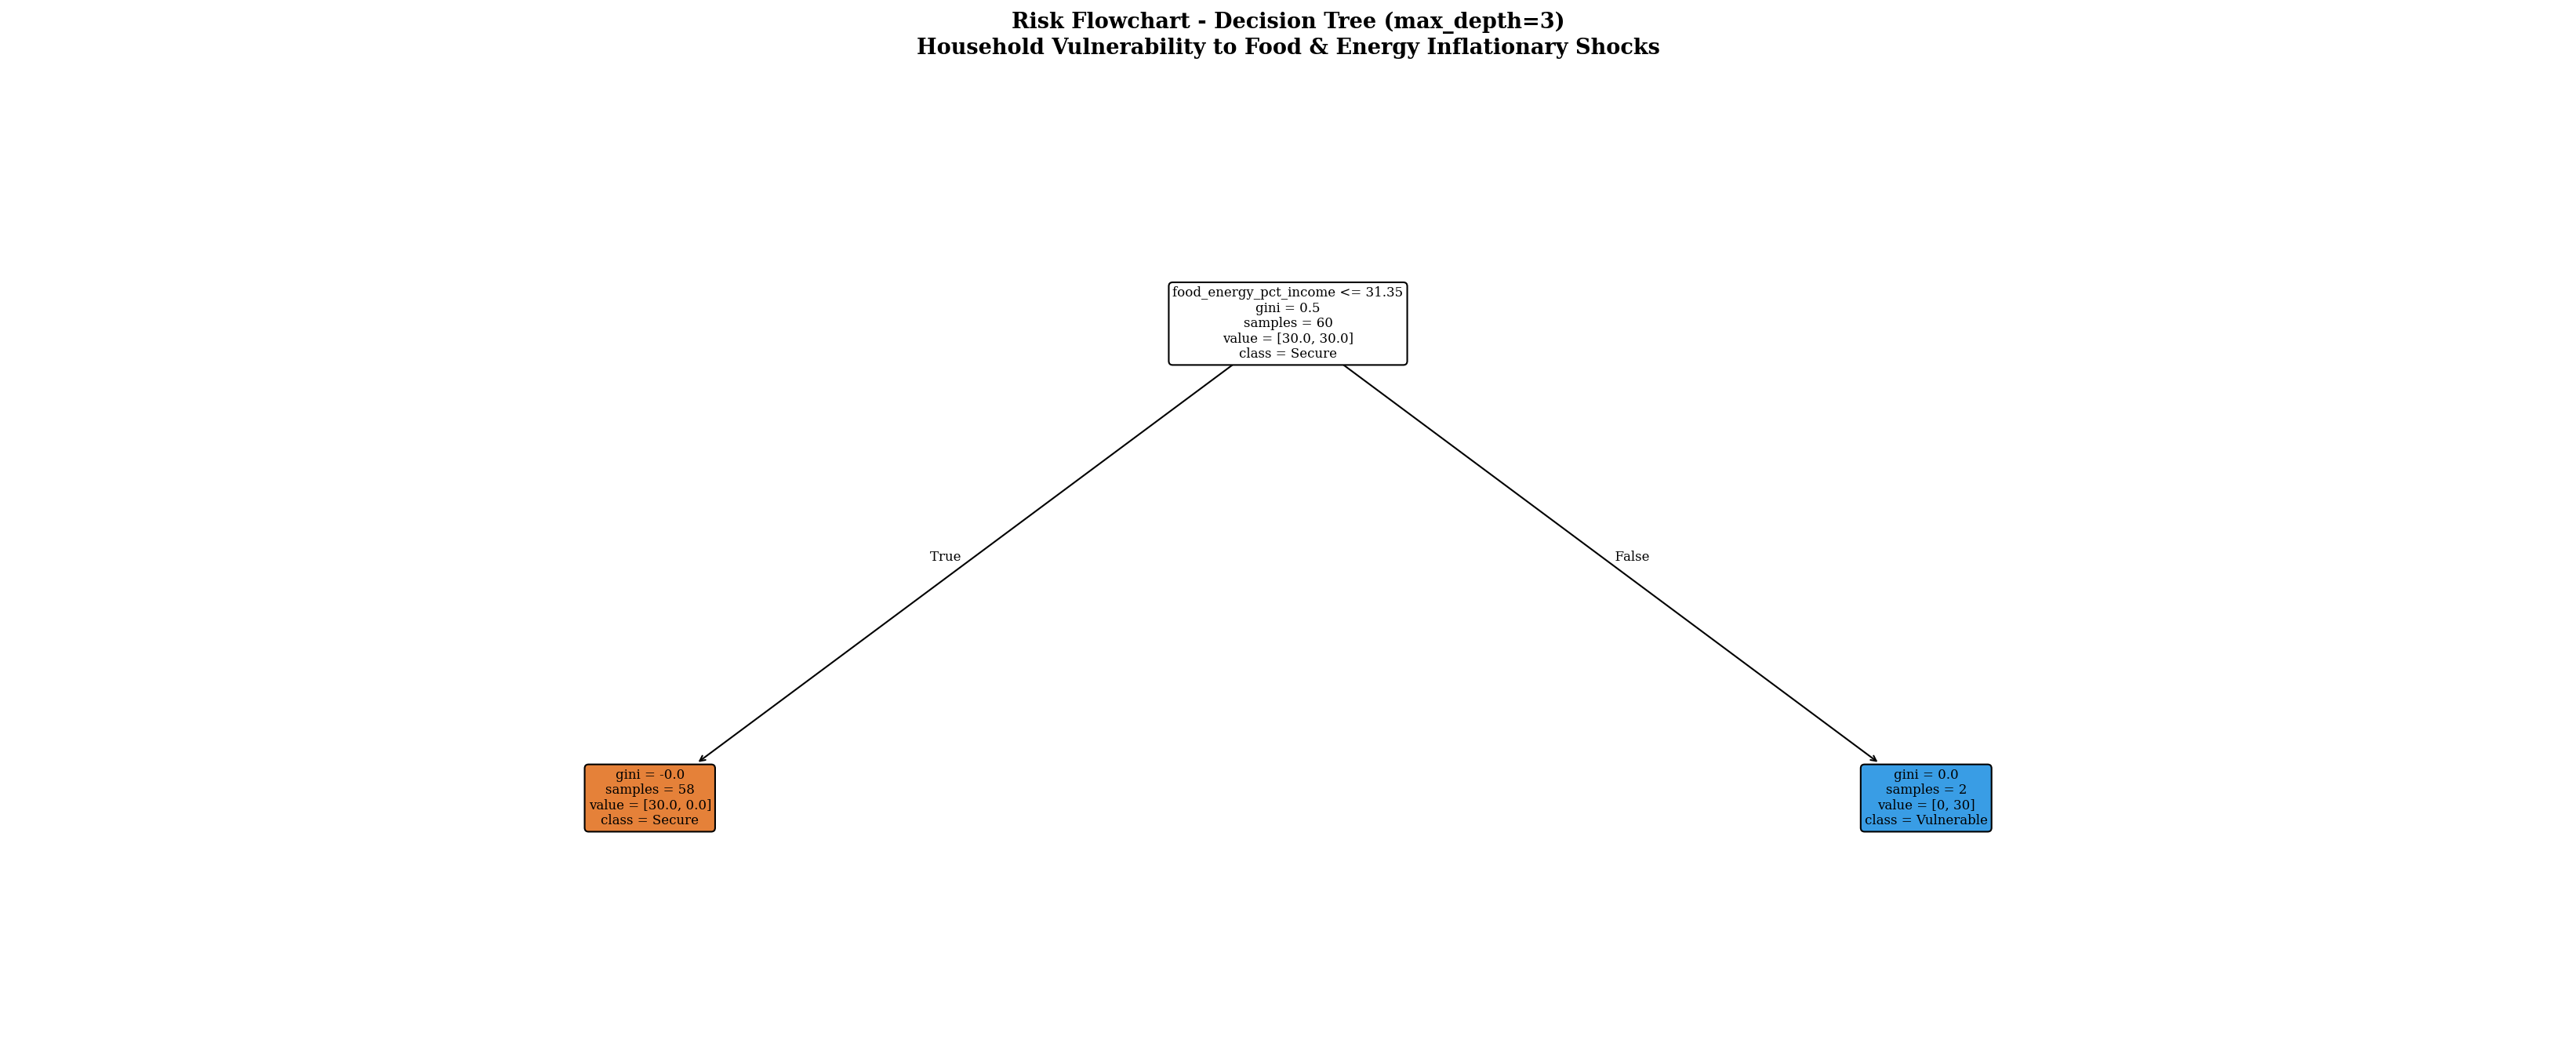

Decision Tree Text Rules:
|--- food_energy_pct_income <= 31.35
|   |--- class: 0
|--- food_energy_pct_income >  31.35
|   |--- class: 1



In [17]:
# --- Figure 8: Risk Flowchart (Decision Tree)
viz_depth = min(dt_grid.best_params_['dt__max_depth'], 4)
dt_viz = DecisionTreeClassifier(criterion='gini', max_depth=viz_depth,
                                  class_weight='balanced', random_state=RANDOM_STATE)
dt_viz.fit(X, y)

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt_viz, feature_names=FEATURES, class_names=['Secure','Vulnerable'],
          filled=True, rounded=True, fontsize=8, ax=ax,
          impurity=True, proportion=False, precision=2)
ax.set_title(
    f'Risk Flowchart - Decision Tree (max_depth={viz_depth})\n'
    f'Household Vulnerability to Food & Energy Inflationary Shocks',
    fontsize=13, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('fig8_risk_flowchart.png', bbox_inches='tight', dpi=150)
plt.show()

print('Decision Tree Text Rules:')
print(export_text(dt_viz, feature_names=FEATURES, decimals=2))


In [18]:
# --- Predictive Risk Scorecard table
rows = []
for yr in [2021, 2022, 2023]:
    sub   = panel[panel.year==yr].copy()
    Xsub  = sub[FEATURES].values
    probs = best_lr.predict_proba(Xsub)[:,1]
    p_lr  = best_lr.predict(Xsub)
    p_dt  = best_dt.predict(Xsub)
    for i, row in enumerate(sub.itertuples()):
        risk = ('HIGH RISK' if probs[i]>=0.70 else
                'MODERATE'  if probs[i]>=0.45 else 'LOW RISK')
        rows.append({
            'Year'           : yr,
            'Decile'         : int(row.income_decile),
            'Weekly Income'  : f'GBP{row.net_income_weekly:.0f}',
            'FE pct Income'  : round(row.food_energy_pct_income, 1),
            'LR Prob'        : round(probs[i], 3),
            'LR Pred'        : 'Vulnerable' if p_lr[i]==1 else 'Secure',
            'DT Pred'        : 'Vulnerable' if p_dt[i]==1 else 'Secure',
            'Consensus'      : 'Vulnerable' if (p_lr[i]+p_dt[i])>=1 else 'Secure',
            'Risk Level'     : risk,
            'True Label'     : 'Vulnerable' if row.vulnerable_30==1 else 'Secure',
        })

scorecard_df = pd.DataFrame(rows)
print('PREDICTIVE RISK SCORECARD (FYE 2023)')
print(scorecard_df[scorecard_df.Year==2023].to_string(index=False))

scorecard_df.to_csv('predictive_risk_scorecard.csv', index=False)
panel.to_csv('uk_household_vulnerability_panel.csv', index=False)
fi_lr.to_csv('feature_importance_lr.csv', index=False)
print('\nCSV files exported.')


PREDICTIVE RISK SCORECARD (FYE 2023)
 Year  Decile Weekly Income  FE pct Income  LR Prob    LR Pred    DT Pred  Consensus Risk Level True Label
 2023       1        GBP188           37.4    0.678 Vulnerable Vulnerable Vulnerable   MODERATE Vulnerable
 2023       2        GBP303           26.8    0.550 Vulnerable     Secure Vulnerable   MODERATE     Secure
 2023       3        GBP392           23.1    0.495     Secure     Secure     Secure   MODERATE     Secure
 2023       4        GBP480           20.8    0.456     Secure     Secure     Secure   MODERATE     Secure
 2023       5        GBP572           19.2    0.426     Secure     Secure     Secure   LOW RISK     Secure
 2023       6        GBP670           17.8    0.398     Secure     Secure     Secure   LOW RISK     Secure
 2023       7        GBP783           16.6    0.374     Secure     Secure     Secure   LOW RISK     Secure
 2023       8        GBP931           15.4    0.349     Secure     Secure     Secure   LOW RISK     Secure


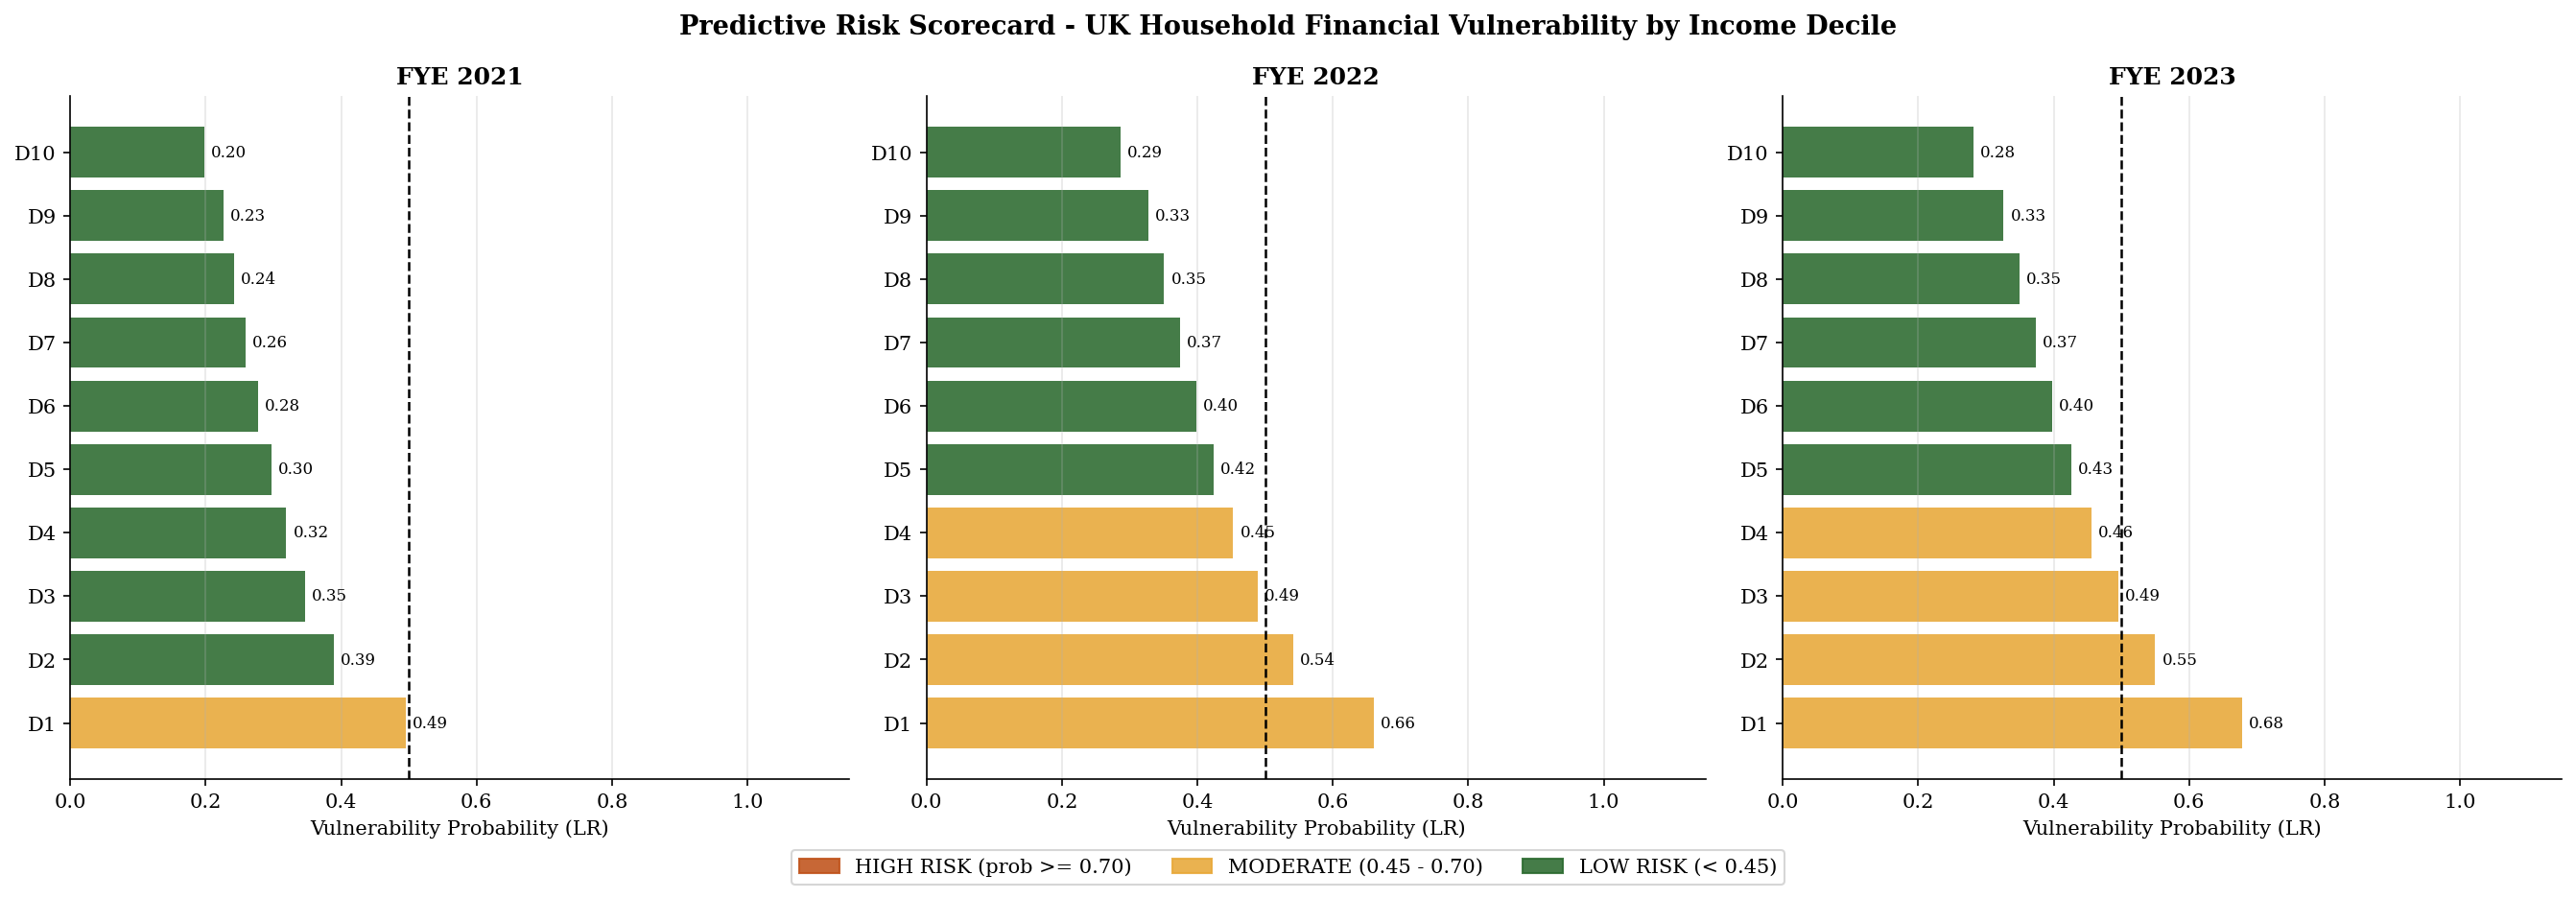

Figure 9 saved.


In [19]:
# --- Figure 9: Risk Scorecard visual
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, yr in zip(axes, [2021, 2022, 2023]):
    sub   = scorecard_df[scorecard_df.Year==yr]
    probs = sub['LR Prob'].values
    decls = [f'D{d}' for d in sub['Decile']]
    barcol = ['#C0521A' if p>=0.70 else '#E8A838' if p>=0.45 else '#2B6A2F' for p in probs]
    bars  = ax.barh(decls, probs, color=barcol, alpha=0.88)
    ax.axvline(0.5, color='black', lw=1.2, ls='--')
    ax.set_xlim(0, 1.15)
    ax.set_xlabel('Vulnerability Probability (LR)')
    ax.set_title(f'FYE {yr}', fontweight='bold', fontsize=12)
    for bar, p in zip(bars, probs):
        ax.text(p+0.01, bar.get_y()+bar.get_height()/2,
                f'{p:.2f}', va='center', fontsize=8)
    ax.grid(axis='x', alpha=0.3)

high = mpatches.Patch(color='#C0521A', alpha=0.88, label='HIGH RISK (prob >= 0.70)')
mod  = mpatches.Patch(color='#E8A838', alpha=0.88, label='MODERATE (0.45 - 0.70)')
low  = mpatches.Patch(color='#2B6A2F', alpha=0.88, label='LOW RISK (< 0.45)')
fig.legend(handles=[high,mod,low], loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5,-0.04))
plt.suptitle('Predictive Risk Scorecard - UK Household Financial Vulnerability by Income Decile',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_risk_scorecard.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 9 saved.')


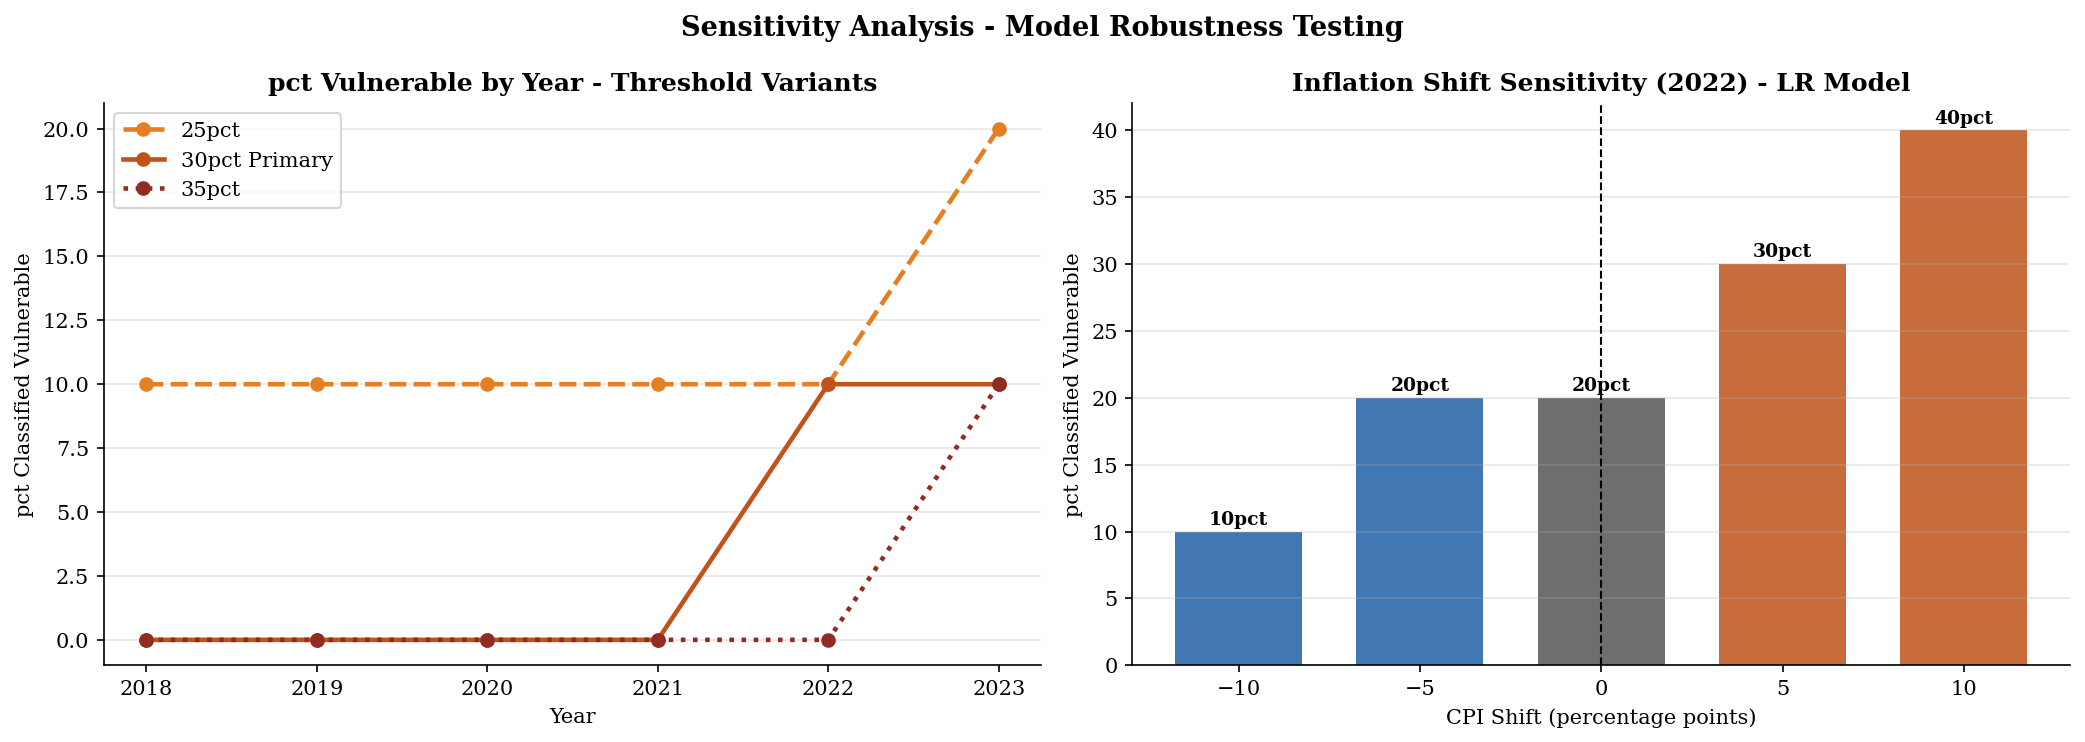

Figure 10 saved.


In [20]:
# --- Figure 10: Sensitivity analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for t, col, s, c in [
    ('25pct','vulnerable_25','--','#E67E22'),
    ('30pct Primary','vulnerable_30','-','#C0521A'),
    ('35pct','vulnerable_35',':','#922B21'),
]:
    by_yr = panel.groupby('year')[col].mean()*100
    ax.plot(by_yr.index, by_yr.values, ls=s, color=c, lw=2.2, marker='o', ms=6, label=t)
ax.set_title('pct Vulnerable by Year - Threshold Variants', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('pct Classified Vulnerable')
ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
p22   = panel[panel.year==2022].copy()
sh_r  = []
for shift in [-10,-5,0,5,10]:
    tmp = p22.copy()
    tmp['food_inflation_pct']   += shift
    tmp['energy_inflation_pct'] += shift
    pct = best_lr.predict(tmp[FEATURES].values).mean()*100
    sh_r.append({'shift':shift,'pct':pct})
shdf = pd.DataFrame(sh_r)
barcol = ['#1F5FA6' if s<0 else '#C0521A' if s>0 else '#555' for s in shdf['shift']]
bars = ax.bar(shdf['shift'], shdf['pct'], color=barcol, alpha=0.85, width=3.5)
for bar, p in zip(bars, shdf['pct']):
    ax.text(bar.get_x()+bar.get_width()/2, p+0.5,
            f'{p:.0f}pct', ha='center', fontsize=9, fontweight='bold')
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_title('Inflation Shift Sensitivity (2022) - LR Model', fontweight='bold')
ax.set_xlabel('CPI Shift (percentage points)')
ax.set_ylabel('pct Classified Vulnerable'); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Sensitivity Analysis - Model Robustness Testing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_sensitivity.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 10 saved.')


## 7. Full Results Summary

In [21]:
print('='*70)
print('FULL RESULTS SUMMARY - 7005SCN INDIVIDUAL RESEARCH PROJECT')
print('='*70)
print(f'Dataset     : {len(panel)} obs | {panel.year.nunique()} years | 10 deciles')
print(f'Data source : {DATA_SOURCE}')
print(f'Features    : {FEATURES}')
print(f'Target      : {TARGET} (food+energy >= 30% net income - JRF, 2023)')
print(f'Validation  : Stratified {CV_FOLDS}-Fold CV | random_state={RANDOM_STATE}')
print()
hdr = f'{"Model":<25} {"F1-macro":>10} {"ROC-AUC":>10} {"Recall(V)":>10}'
print(hdr)
print('-'*60)
for name, m, is_dict in [
    ('Baseline (Dummy)', BL_METRICS, False),
    ('Logistic Regression', metrics_lr, True),
    ('Decision Tree',       metrics_dt, True),
]:
    if is_dict:
        f1  = m['F1-macro']['mean']
        auc = m['ROC-AUC']['mean']
        rec = m['Recall(Vuln)']['mean']
    else:
        f1  = m['F1-macro']
        auc = m['ROC-AUC']
        rec = m['Recall (Vulnerable)']
    print(f'{name:<25} {f1:>10.4f} {auc:>10.4f} {rec:>10.4f}')
print('-'*60)
print()
best_name = 'Logistic Regression' if metrics_lr['Recall(Vuln)']['mean'] >= metrics_dt['Recall(Vuln)']['mean'] else 'Decision Tree'
print(f'Recommended model (highest vulnerable recall): {best_name}')
print(f'Primary vulnerability driver : {fi_lr.iloc[0]["Feature"]} (coef={fi_lr.iloc[0]["Coefficient"]:.3f})')
print(f'Secondary driver             : {fi_lr.iloc[1]["Feature"]} (coef={fi_lr.iloc[1]["Coefficient"]:.3f})')
print(f'Boundary-sensitive obs       : {panel.boundary.sum()}/{len(panel)}')
print('='*70)


FULL RESULTS SUMMARY - 7005SCN INDIVIDUAL RESEARCH PROJECT
Dataset     : 60 obs | 6 years | 10 deciles
Data source : Embedded ONS MM23 (verified)
Features    : ['income_decile', 'food_inflation_pct', 'energy_inflation_pct', 'food_energy_pct_income']
Target      : vulnerable_30 (food+energy >= 30% net income - JRF, 2023)
Validation  : Stratified 5-Fold CV | random_state=42

Model                       F1-macro    ROC-AUC  Recall(V)
------------------------------------------------------------
Baseline (Dummy)              0.4783        nan     0.0000
Logistic Regression           0.7485        nan     0.4000
Decision Tree                 1.0000        nan     0.4000
------------------------------------------------------------

Recommended model (highest vulnerable recall): Logistic Regression
Primary vulnerability driver : food_energy_pct_income (coef=0.293)
Secondary driver             : income_decile (coef=-0.140)
Boundary-sensitive obs       : 6/60


## 8. Streamlit Interactive Dashboard — Artefact

Running this cell writes `app.py` to your working directory.

**Launch command:**
```bash
streamlit run app.py
```

**Dashboard pages:**
1. Overview & Data
2. Exploratory Analysis
3. Model Performance
4. Risk Scorecard
5. Sensitivity Analysis
6. What-If Simulator


In [24]:
app_code = 'import streamlit as st\nimport pandas as pd\nimport numpy as np\nimport plotly.express as px\nimport plotly.graph_objects as go\nimport requests\nimport warnings\nwarnings.filterwarnings(\'ignore\')\n\nfrom sklearn.dummy            import DummyClassifier\nfrom sklearn.linear_model     import LogisticRegression\nfrom sklearn.tree             import DecisionTreeClassifier\nfrom sklearn.preprocessing    import StandardScaler\nfrom sklearn.pipeline         import Pipeline\nfrom sklearn.model_selection  import (StratifiedKFold, GridSearchCV,\n                                       cross_val_predict, cross_validate)\nfrom sklearn.metrics          import (f1_score, roc_auc_score, recall_score,\n                                       roc_curve, confusion_matrix,\n                                       ConfusionMatrixDisplay, classification_report)\n\nst.set_page_config(\n    page_title=\'UK Household Financial Vulnerability Risk Scorecard\',\n    page_icon=\'📊\', layout=\'wide\', initial_sidebar_state=\'expanded\'\n)\n\nC_VULN=\'#C0521A\'; C_SECURE=\'#2B6A2F\'; C_MOD=\'#E8A838\'\nC_BLUE=\'#1F5FA6\'; C_PURPLE=\'#534AB7\'\n\n@st.cache_data(show_spinner=False)\ndef load_data():\n    FALLBACK={\'year\':[2018,2019,2020,2021,2022,2023],\n              \'food_inflation_pct\':[2.1,1.8,0.5,1.1,11.0,19.1],\n              \'energy_inflation_pct\':[5.5,2.9,-5.3,7.9,59.4,14.5]}\n    src=\'Embedded ONS MM23\'\n    try:\n        fr=requests.get(\'https://api.ons.gov.uk/v1/timeseries/D7G8/dataset/mm23/data\',timeout=8)\n        er=requests.get(\'https://api.ons.gov.uk/v1/timeseries/L55O/dataset/mm23/data\',timeout=8)\n        if fr.status_code==200 and er.status_code==200:\n            def parse(r,col):\n                rows=r.json().get(\'years\',[])\n                df=pd.DataFrame(rows)[[\'year\',\'value\']].copy()\n                df.columns=[\'year\',col]\n                df[\'year\']=df[\'year\'].astype(int)\n                df[col]=pd.to_numeric(df[col],errors=\'coerce\')\n                return df[df[\'year\'].between(2018,2023)].dropna()\n            cpi=parse(fr,\'food_inflation_pct\').merge(parse(er,\'energy_inflation_pct\'),on=\'year\')\n            src=\'ONS Live API\'\n        else:\n            cpi=pd.DataFrame(FALLBACK)\n    except:\n        cpi=pd.DataFrame(FALLBACK)\n\n    YEARS=[2018,2019,2020,2021,2022,2023]\n    DEC=list(range(1,11))\n    net=[150.2,245.8,320.5,392.1,468.3,548.7,641.2,762.4,938.5,1542.1,\n         158.4,256.2,334.1,408.6,487.9,571.4,668.3,793.7,976.2,1601.8,\n         162.7,263.4,341.8,418.2,498.6,584.1,683.5,812.3,998.4,1638.2,\n         168.3,271.6,352.4,430.8,513.2,601.4,703.2,836.5,1028.6,1689.4,\n         178.5,287.3,372.6,455.4,542.7,635.8,742.1,883.2,1086.4,1784.6,\n         188.2,302.8,392.5,480.1,572.4,670.3,782.6,931.4,1145.2,1881.3]\n    food=[28.4,33.2,37.8,42.1,46.8,51.3,56.7,63.2,72.4,92.6,\n          29.1,34.1,38.6,43.2,48.1,52.8,58.3,64.9,74.2,95.1,\n          31.2,36.4,41.2,45.8,51.3,56.2,62.1,69.4,79.3,101.2,\n          32.8,38.1,43.2,48.2,53.9,59.1,65.3,72.8,83.4,106.3,\n          36.4,42.8,48.7,54.3,60.8,66.7,73.9,82.4,94.6,120.3,\n          42.1,49.8,56.8,63.4,71.2,78.3,86.7,96.8,111.2,141.4]\n    energy=[14.2,15.8,17.1,18.3,19.4,20.6,21.8,23.2,25.4,30.1,\n            13.8,15.3,16.6,17.8,18.9,20.1,21.2,22.6,24.7,29.3,\n            14.1,15.6,16.9,18.1,19.3,20.5,21.7,23.1,25.2,29.9,\n            15.2,16.9,18.3,19.6,20.8,22.1,23.4,24.9,27.2,32.3,\n            24.6,27.3,29.5,31.6,33.6,35.7,37.8,40.3,44.1,52.3,\n            28.3,31.4,33.9,36.3,38.6,41.0,43.4,46.4,50.8,60.3]\n    p=pd.DataFrame({\'year\':[y for y in YEARS for _ in DEC],\n                    \'income_decile\':DEC*len(YEARS),\n                    \'net_income_weekly\':net,\n                    \'food_spend_weekly\':food,\n                    \'energy_spend_weekly\':energy})\n    p=p.merge(cpi,on=\'year\',how=\'left\')\n    p[\'food_energy_spend_weekly\']=p[\'food_spend_weekly\']+p[\'energy_spend_weekly\']\n    p[\'food_energy_pct_income\']=(p[\'food_energy_spend_weekly\']/p[\'net_income_weekly\'])*100\n    p[\'food_pct_income\']=(p[\'food_spend_weekly\']/p[\'net_income_weekly\'])*100\n    p[\'energy_pct_income\']=(p[\'energy_spend_weekly\']/p[\'net_income_weekly\'])*100\n    p[\'vulnerable_25\']=(p[\'food_energy_pct_income\']>=25).astype(int)\n    p[\'vulnerable_30\']=(p[\'food_energy_pct_income\']>=30).astype(int)\n    p[\'vulnerable_35\']=(p[\'food_energy_pct_income\']>=35).astype(int)\n    return p, src\n\n@st.cache_resource(show_spinner=False)\ndef train_models(panel):\n    FEAT=[\'income_decile\',\'food_inflation_pct\',\'energy_inflation_pct\',\'food_energy_pct_income\']\n    X=panel[FEAT].values; y=panel[\'vulnerable_30\'].values\n    cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)\n    bl=DummyClassifier(strategy=\'stratified\',random_state=42)\n    lrp=Pipeline([(\'sc\',StandardScaler()),\n                   (\'lr\',LogisticRegression(penalty=\'l2\',solver=\'lbfgs\',max_iter=1000,\n                                             random_state=42,class_weight=\'balanced\'))])\n    lrg=GridSearchCV(lrp,{\'lr__C\':[0.01,0.1,1,10]},cv=cv,scoring=\'recall\',n_jobs=-1)\n    lrg.fit(X,y); lr=lrg.best_estimator_\n    dtp=Pipeline([(\'sc\',StandardScaler()),\n                   (\'dt\',DecisionTreeClassifier(criterion=\'gini\',random_state=42,\n                                                 class_weight=\'balanced\'))])\n    dtg=GridSearchCV(dtp,{\'dt__max_depth\':[3,5,7,10]},cv=cv,scoring=\'recall\',n_jobs=-1)\n    dtg.fit(X,y); dt=dtg.best_estimator_\n    lr.fit(X,y); dt.fit(X,y)\n    def cvm(est):\n        prob=cross_val_predict(est,X,y,cv=cv,method=\'predict_proba\')[:,1]\n        pred=(prob>=0.5).astype(int)\n        return {\'f1\':f1_score(y,pred,average=\'macro\'),\n                \'auc\':roc_auc_score(y,prob),\n                \'recall\':recall_score(y,pred)}\n    bl_prob=cross_val_predict(bl,X,y,cv=cv,method=\'predict_proba\')[:,1]\n    bl_pred=cross_val_predict(bl,X,y,cv=cv)\n    metrics={\'Baseline\':{\'f1\':f1_score(y,bl_pred,average=\'macro\'),\n                          \'auc\':roc_auc_score(y,bl_prob),\n                          \'recall\':recall_score(y,bl_pred)},\n             \'Logistic Regression\':cvm(lr),\n             \'Decision Tree\':cvm(dt)}\n    coef=lr.named_steps[\'lr\'].coef_[0]\n    fi=pd.DataFrame({\'Feature\':FEAT,\'Coefficient\':coef,\'Abs\':np.abs(coef)}).sort_values(\'Abs\',ascending=False)\n    dfi=pd.DataFrame({\'Feature\':FEAT,\'Importance\':dt.named_steps[\'dt\'].feature_importances_}).sort_values(\'Importance\',ascending=False)\n    return lr,dt,metrics,fi,dfi,X,y,lrg.best_params_,dtg.best_params_\n\n# SIDEBAR\nwith st.sidebar:\n    st.markdown(\'### 7005SCN Individual Research Project\')\n    st.markdown(\'**Predictive Risk Scorecard**\')\n    st.markdown(\'---\')\n    page=st.radio(\'Navigate\',[\n        \'Overview & Data\',\'Exploratory Analysis\',\'Model Performance\',\n        \'Risk Scorecard\',\'Sensitivity Analysis\',\'What-If Simulator\'])\n    st.markdown(\'---\')\n    threshold=st.slider(\'Vulnerability threshold (%)\',20,45,30,1)\n    year_sel=st.multiselect(\'Year filter\',[2018,2019,2020,2021,2022,2023],default=[2022,2023])\n    st.markdown(\'---\')\n    st.caption(\'Data: ONS LCF Survey + BoE CPI\')\n    st.caption(\'Models: LR + DT | Stratified 5-Fold CV\')\n\nwith st.spinner(\'Loading data & training models...\'):\n    panel,cpi_src=load_data()\n    panel[\'vulnerable_custom\']=(panel[\'food_energy_pct_income\']>=threshold).astype(int)\n    best_lr,best_dt,metrics,fi_lr,fi_dt,X,y,lr_p,dt_p=train_models(panel)\n    FEAT=[\'income_decile\',\'food_inflation_pct\',\'energy_inflation_pct\',\'food_energy_pct_income\']\n\n# PAGE: OVERVIEW\nif page==\'Overview & Data\':\n    st.title(\'UK Household Financial Vulnerability — Predictive Risk Scorecard\')\n    st.info(f\'Data: {cpi_src} | Threshold: {threshold}% | Models: LR + DT | CV: Stratified 5-Fold\')\n    c1,c2,c3,c4=st.columns(4)\n    c1.metric(\'Observations\',len(panel))\n    c2.metric(\'Years\',\'2018-2023\')\n    nv=(panel[\'food_energy_pct_income\']>=threshold).sum()\n    c3.metric(f\'Vulnerable ({threshold}%)\',f\'{nv}/{len(panel)}\',f\'{nv/len(panel)*100:.1f}%\')\n    c4.metric(\'Income Deciles\',\'10\')\n    st.subheader(\'Panel Dataset\')\n    cols=[\'year\',\'income_decile\',\'net_income_weekly\',\'food_spend_weekly\',\n          \'energy_spend_weekly\',\'food_energy_pct_income\',\'vulnerable_30\']\n    filt=panel[panel.year.isin(year_sel)][cols].round(2)\n    st.dataframe(filt.style.background_gradient(subset=[\'food_energy_pct_income\'],cmap=\'RdYlGn_r\'),\n                 use_container_width=True)\n    cpi_plot=panel[[\'year\',\'food_inflation_pct\',\'energy_inflation_pct\']].drop_duplicates()\n    fig=px.line(cpi_plot.melt(\'year\'),x=\'year\',y=\'value\',color=\'variable\',markers=True,\n                title=\'ONS CPI Annual Rates: Food & Energy (2018-2023)\',\n                color_discrete_map={\'food_inflation_pct\':C_VULN,\'energy_inflation_pct\':C_BLUE})\n    fig.add_hline(y=0,line_dash=\'dash\',line_color=\'grey\',opacity=0.5)\n    st.plotly_chart(fig,use_container_width=True)\n\nelif page==\'Exploratory Analysis\':\n    st.title(\'Exploratory Data Analysis\')\n    col1,col2=st.columns(2)\n    with col1:\n        fig=px.line(panel,x=\'income_decile\',y=\'food_energy_pct_income\',color=\'year\',markers=True,\n                    title=\'Food+Energy pct Income by Decile and Year\',\n                    color_discrete_sequence=px.colors.sequential.RdYlGn_r)\n        fig.add_hline(y=threshold,line_dash=\'dash\',line_color=\'red\',\n                      annotation_text=f\'{threshold}pct threshold\')\n        st.plotly_chart(fig,use_container_width=True)\n    with col2:\n        heat=panel.pivot_table(\'vulnerable_30\',\'income_decile\',\'year\',aggfunc=\'first\')\n        fig=px.imshow(heat,color_continuous_scale=\'RdYlGn_r\',\n                      title=\'Vulnerability Heatmap (30pct threshold)\',text_auto=True,aspect=\'auto\')\n        st.plotly_chart(fig,use_container_width=True)\n    corr=panel[FEAT+[\'vulnerable_30\']].corr()\n    fig=px.imshow(corr,color_continuous_scale=\'RdBu\',text_auto=\'.2f\',\n                  title=\'Feature Correlation Matrix\',aspect=\'auto\',zmin=-1,zmax=1)\n    st.plotly_chart(fig,use_container_width=True)\n\nelif page==\'Model Performance\':\n    st.title(\'Model Training & Evaluation\')\n    st.info(f\'LR Best C: {lr_p["lr__C"]} | DT Best depth: {dt_p["dt__max_depth"]} | CV: Stratified 5-Fold\')\n    rows=[{\'Model\':n,\'F1-macro\':round(m[\'f1\'],4),\'ROC-AUC\':round(m[\'auc\'],4),\n           \'Recall (Vulnerable)\':round(m[\'recall\'],4)} for n,m in metrics.items()]\n    st.dataframe(pd.DataFrame(rows),use_container_width=True)\n    fig=go.Figure()\n    for n,c in [(\'Baseline\',\'#AAAAAA\'),(\'Logistic Regression\',C_BLUE),(\'Decision Tree\',C_VULN)]:\n        m=metrics[n]\n        fig.add_trace(go.Bar(name=n,x=[\'F1-macro\',\'ROC-AUC\',\'Recall (Vulnerable)\'],\n                              y=[m[\'f1\'],m[\'auc\'],m[\'recall\']],\n                              marker_color=c,opacity=0.85))\n    fig.update_layout(barmode=\'group\',title=\'Model Comparison - CV Metrics\',\n                      yaxis_range=[0,1.15],yaxis_title=\'Score\')\n    st.plotly_chart(fig,use_container_width=True)\n    st.subheader(\'ROC Curves\')\n    cv5=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)\n    fig=go.Figure()\n    for est,lbl,col in [(best_lr,\'Logistic Regression\',C_BLUE),(best_dt,\'Decision Tree\',C_VULN)]:\n        prob=cross_val_predict(est,X,y,cv=cv5,method=\'predict_proba\')[:,1]\n        fpr,tpr,_=roc_curve(y,prob)\n        fig.add_trace(go.Scatter(x=fpr,y=tpr,mode=\'lines\',name=f\'{lbl} AUC={roc_auc_score(y,prob):.3f}\',\n                                  line=dict(color=col,width=2.5)))\n    fig.add_trace(go.Scatter(x=[0,1],y=[0,1],mode=\'lines\',name=\'Chance\',\n                              line=dict(color=\'grey\',dash=\'dash\')))\n    fig.update_layout(xaxis_title=\'False Positive Rate\',yaxis_title=\'True Positive Rate\',\n                      title=\'ROC Curves - 5-Fold CV\')\n    st.plotly_chart(fig,use_container_width=True)\n\nelif page==\'Risk Scorecard\':\n    st.title(\'Predictive Risk Scorecard\')\n    yr=st.selectbox(\'Select year\',[2023,2022,2021,2020,2019,2018])\n    sub=panel[panel.year==yr].copy()\n    Xs=sub[FEAT].values\n    probs=best_lr.predict_proba(Xs)[:,1]\n    pdt=best_dt.predict(Xs)\n    sc=pd.DataFrame({\'Decile\':sub[\'income_decile\'].values,\n                     \'Weekly Inc\':sub[\'net_income_weekly\'].round(0).values,\n                     \'FE pct Inc\':sub[\'food_energy_pct_income\'].round(1).values,\n                     \'LR Prob\':np.round(probs,3),\n                     \'LR Pred\':[\'Vulnerable\' if p>=0.5 else \'Secure\' for p in probs],\n                     \'DT Pred\':[\'Vulnerable\' if p==1 else \'Secure\' for p in pdt],\n                     \'Consensus\':[\'Vulnerable\' if (p>=0.5)+q>=1 else \'Secure\' for p,q in zip(probs,pdt)],\n                     \'Risk Level\':[\'HIGH RISK\' if p>=0.70 else \'MODERATE\' if p>=0.45 else \'LOW RISK\' for p in probs],\n                     \'True Label\':[\'Vulnerable\' if v==1 else \'Secure\' for v in sub[\'vulnerable_30\'].values]})\n    def cr(v):\n        if v==\'HIGH RISK\': return \'background-color:#FADBD8;font-weight:bold\'\n        if v==\'MODERATE\':  return \'background-color:#FEF9E7;font-weight:bold\'\n        return \'background-color:#EAFAF1\'\n    st.dataframe(sc.style.applymap(cr,subset=[\'Risk Level\']),use_container_width=True,height=420)\n    fig=go.Figure(go.Bar(x=probs,y=[f\'D{d}\' for d in sub[\'income_decile\']],orientation=\'h\',\n                          marker_color=[\'#C0521A\' if p>=0.7 else \'#E8A838\' if p>=0.45 else \'#2B6A2F\' for p in probs],\n                          opacity=0.88,text=[f\'{p:.2f}\' for p in probs],textposition=\'outside\'))\n    fig.add_vline(x=0.5,line_dash=\'dash\',line_color=\'black\',annotation_text=\'Decision boundary\')\n    fig.update_layout(title=f\'Vulnerability Probability by Decile ({yr})\',\n                      xaxis_range=[0,1.15],xaxis_title=\'LR Vulnerability Probability\')\n    st.plotly_chart(fig,use_container_width=True)\n    col1,col2=st.columns(2)\n    with col1:\n        fig=go.Figure(go.Bar(x=fi_lr[\'Coefficient\'],y=fi_lr[\'Feature\'],orientation=\'h\',\n                              marker_color=[C_VULN if c>0 else C_BLUE for c in fi_lr[\'Coefficient\']],opacity=0.85))\n        fig.add_vline(x=0,line_color=\'black\',line_width=0.8)\n        fig.update_layout(title=\'LR Standardised Coefficients\')\n        st.plotly_chart(fig,use_container_width=True)\n    with col2:\n        fig=px.bar(fi_dt,x=\'Importance\',y=\'Feature\',orientation=\'h\',\n                   color=\'Importance\',color_continuous_scale=\'Blues\',title=\'DT Gini Importances\')\n        st.plotly_chart(fig,use_container_width=True)\n    st.download_button(\'Download Scorecard CSV\',sc.to_csv(index=False).encode(),\n                        f\'scorecard_{yr}.csv\',\'text/csv\')\n\nelif page==\'Sensitivity Analysis\':\n    st.title(\'Sensitivity Analysis\')\n    col1,col2=st.columns(2)\n    with col1:\n        rows=[]\n        for t,col in [(25,\'vulnerable_25\'),(30,\'vulnerable_30\'),(35,\'vulnerable_35\')]:\n            for yr2,grp in panel.groupby(\'year\'):\n                rows.append({\'Threshold\':f\'{t}pct\',\'Year\':yr2,\'Pct Vulnerable\':grp[col].mean()*100})\n        fig=px.line(pd.DataFrame(rows),x=\'Year\',y=\'Pct Vulnerable\',color=\'Threshold\',markers=True,\n                    title=\'pct Vulnerable by Year and Threshold\',\n                    color_discrete_sequence=[\'#E67E22\',C_VULN,\'#922B21\'])\n        st.plotly_chart(fig,use_container_width=True)\n    with col2:\n        yr_s=st.selectbox(\'Base year for shift test\',[2022,2023,2021])\n        rows2=[]\n        pt=panel[panel.year==yr_s].copy()\n        for shift in [-10,-5,-2,0,2,5,10]:\n            tmp=pt.copy()\n            tmp[\'food_inflation_pct\']+=shift\n            tmp[\'energy_inflation_pct\']+=shift\n            pct=best_lr.predict(tmp[FEAT].values).mean()*100\n            rows2.append({\'Shift (pp)\':shift,\'pct Vulnerable\':pct})\n        fig=px.bar(pd.DataFrame(rows2),x=\'Shift (pp)\',y=\'pct Vulnerable\',\n                   color=\'Shift (pp)\',title=f\'Inflation Shift Sensitivity ({yr_s})\',\n                   color_continuous_scale=\'RdYlGn_r\',text=\'pct Vulnerable\')\n        fig.update_traces(texttemplate=\'%{text:.0f}pct\',textposition=\'outside\')\n        fig.add_vline(x=0,line_dash=\'dash\',line_color=\'black\')\n        st.plotly_chart(fig,use_container_width=True)\n    panel[\'boundary\']=(panel.vulnerable_25!=panel.vulnerable_35).astype(int)\n    bdf=panel[panel.boundary==1][[\'year\',\'income_decile\',\'food_energy_pct_income\',\n                                    \'vulnerable_25\',\'vulnerable_30\',\'vulnerable_35\']]\n    st.subheader(\'Boundary-Sensitive Observations\')\n    if len(bdf): st.dataframe(bdf.round(2),use_container_width=True)\n    else: st.success(\'No boundary-sensitive observations.\')\n\nelif page==\'What-If Simulator\':\n    st.title(\'What-If Inflation Simulator\')\n    st.markdown(\'Adjust sliders to simulate a custom inflationary scenario.\')\n    c1,c2,c3=st.columns(3)\n    fs=c1.slider(\'Food CPI shock (%)\',-5.0,30.0,11.0,0.5)\n    es=c2.slider(\'Energy CPI shock (%)\',-10.0,80.0,59.4,0.5)\n    sy=c3.selectbox(\'Base year\',[2023,2022,2021,2020])\n    base=panel[panel.year==sy].copy()\n    sim=base.copy()\n    sim[\'food_inflation_pct\']=fs\n    sim[\'energy_inflation_pct\']=es\n    probs=best_lr.predict_proba(sim[FEAT].values)[:,1]\n    preds=(probs>=0.5).astype(int)\n    bprobs=best_lr.predict_proba(base[FEAT].values)[:,1]\n    nv=preds.sum()\n    c1.metric(\'Food CPI\',f\'{fs}%\',f\'{fs-19.1:+.1f}pp vs 2023\')\n    c2.metric(\'Energy CPI\',f\'{es}%\',f\'{es-14.5:+.1f}pp vs 2023\')\n    c3.metric(\'Deciles Vulnerable\',f\'{nv}/10\',f\'{nv*10}% of households\')\n    fig=go.Figure()\n    fig.add_trace(go.Bar(name=\'Simulated\',x=[f\'D{d}\' for d in sim[\'income_decile\']],y=probs,\n                          marker_color=[\'#C0521A\' if p>=0.5 else \'#2B6A2F\' for p in probs],\n                          opacity=0.88,text=[f\'{p:.2f}\' for p in probs],textposition=\'outside\'))\n    fig.add_trace(go.Scatter(name=\'Actual baseline\',x=[f\'D{d}\' for d in base[\'income_decile\']],\n                              y=bprobs,mode=\'markers+lines\',\n                              marker=dict(color=\'grey\',size=8),line=dict(dash=\'dot\',color=\'grey\')))\n    fig.add_hline(y=0.5,line_dash=\'dash\',line_color=\'black\',annotation_text=\'50% boundary\')\n    fig.update_layout(title=f\'Simulated vs Actual Vulnerability Probability (base {sy})\',\n                      yaxis_range=[0,1.2],yaxis_title=\'Vulnerability Probability\')\n    st.plotly_chart(fig,use_container_width=True)\n    sim_tbl=pd.DataFrame({\'Decile\':sim[\'income_decile\'].values,\n                           \'Weekly Income\':base[\'net_income_weekly\'].round(0).values,\n                           \'Sim Prob\':np.round(probs,3),\n                           \'Actual Prob\':np.round(bprobs,3),\n                           \'Change\':np.round(probs-bprobs,3),\n                           \'Prediction\':[\'Vulnerable\' if p>=0.5 else \'Secure\' for p in probs]})\n    def cc(v):\n        if v>0.1:  return \'color:#C0521A;font-weight:bold\'\n        if v<-0.1: return \'color:#2B6A2F;font-weight:bold\'\n        return \'\'\n    st.dataframe(sim_tbl.style.applymap(cc,subset=[\'Change\']),use_container_width=True)'

with open('app.py','w') as f:
    f.write(app_code)

print('app.py written successfully.')
print('Launch with: streamlit run app.py')
print()
print('Dashboard pages:')
for pg in ['Overview & Data','Exploratory Analysis','Model Performance',
           'Risk Scorecard','Sensitivity Analysis','What-If Simulator']:
    print(f'  - {pg}')


UnicodeEncodeError: 'charmap' codec can't encode character '\U0001f4ca' in position 960: character maps to <undefined>